# 8장 Variational Inference를 활용한 LDA 구현

## 1. Sampling method의 기여와 한계

앞서 sampling method를 알아봤습니다. 어떤 확률 분포가 복잡하여 그것으로부터 수리적/해석적으로 정보를 얻기 어려울 때 그 분포를 따르는 경험 데이터를 산출하여 이 데이터로부터 정보를 얻는 방법이었습니다. MCMC (Markov Chain Monte Carlo) 기법들이 이 계열의 주류적인 방법이라 할 수 있습니다. 이들은 특히 베이지안 통계 기법에서 많이 활용되었는데, 이는 사후 분포가 수리적/해석적으로 간단한 경우가 오히려 드물기 때문입니다. 복잡한 사후 분포의 정보를 읽어내는 방법으로 활용하는 거죠. 게다가 사후 분포의 복잡성에 기여하는 주요한 요인이 Evidence 파트였는데, MCMC는 이 Evidence 부분을 고려하지 않아도 되도록 설계된 경우가 많습니다. Gibbs 샘플링과 MH 알고리즘이 그랬죠 (자세한 설명은 7장 참조) MCMC가 자주 사용되는 이유 중 하나도 이것입니다. 

하지만 이 sampling method 계열의 방법도 당연히 단점이 있습니다. 연산에 시간이 오래걸린다는 것입니다. 데이터를 산출해서 관심 분포에 대한 정보를 정확히 얻으려면 당연히 데이터가 많아야 합니다. 그리고 앞서 우리가 공부한 방법을 보면, 하나의 데이터를 만드는 데에도 꽤나 많은 과정을 거칩니다. 특히 목표 분포가 다변수 함수일 때 그렇습니다. 예를 들어 우리가 알고 싶은 확률 변수가 총 20개라고 하겠습니다. 이 경우에는 데이터가 길이가 20인 벡터라고 할 수 있습니다. 이런 경우 연산에 시간이 걸리는게 자연스럽습니다. 

1. 일단 하나의 벡터를 만들어내는 것 자체가 생각보다 많은 절차를 필요로 합니다. 차원이 높으니 각 차원에 해당하는 값을 만들어야 하니까요. 예를 들어 이걸 깁스 샘플링으로 하려고 한다고 하죠. 그러면 20개의 full conditional distribution을 유도해서, 개별 변수 각각 마다 샘플링을 해야 합니다. 20번의 샘플링을 거쳐서 하나의 데이터를 완성하는 셈이지요. MH 알고리즘은 어떤가요? 일단 샘플링이 쉬운 적당한 분포 함수를 설정한 후, 거기서 데이터를 얻어내고 acceptance rate을 계산하고 이걸 채택할지 말지 결정합니다. 하나의 데이터를 만드는데 꽤 많은 절차를 거쳐야 하죠. 

2. 또한 이 하나의 데이터를 만드는 과정을 꽤 많이 반복해야 합니다. 목표 분포를 잘 보여주는 데이터 집합을 만들려면, 분포가 커버하는 상태 공간 전체를 훑으면서 데이터를 만들어야 하는데, 변수가 많고 그래서 분포가 커버하는 공간이 고차원일수록 여기에 필요한 데이터 숫자가 매우 빠르게 커집니다. 왜냐하면 다변수는 (항상 그런건 아니지만 많은 경우) 분포 함수에서 local maximum point, 즉 지역적 고확률 지점이 많아질 개연성을 높이고, MCMC가 특정 위치에서 출발해서 근처를 탐색해가며 이동해가는 방식을 따르기 때문입니다. 각각에 대해 좀 더 자세히 설명해보겠습니다. 

    1. 목표 분포 함수가 다변수 함수고 그래서 고차원 공간에서 어떤 패턴을 표현하고 있으면, 지역적 고확률 지점이 많아질 개연성이 큽니다. 변수들이 상호작용할 수 있기 때문입니다. 만약 상호작용이 존재하고 그를 고려해야 한다면, 변수의 종류가 많을 수록 변수들의 조합 다양성이 커지고, 그 중 여러 조합 후보군에서 고확률이 발생할 수 있습니다. 좀 일반적인 예를 들어봅시다. 예를 들어 '집을 가질 확률'이 10개의 변수에 영향을 받는다고 하죠. 월소득, 현재 자산, 교육수준, 부모소득, 부모자산, 현재 부동산 시장 경기, 현재 주식 시장 경기, 현재 대출 정책 등이 그것이라고 합시다. 그러면 집을 가질 확률을 높이는 매우 다양한 경로가 존재하게 됩니다. 누군가는 부모 소득이 높아서 집을 가질 확률이 올라가지만, 누군가는 현재 주식 시장 경기에 영향을 받아서 (즉 거기서 돈을 많이 벌어서) 집을 가질 확률이 올라갑니다. 이렇게 되면, '집을 가질 확률'이 높은 지역이 여럿 형성되는 꼴입니다. 지역적 고확률 지점이 많아진다는 거죠. 반면 집을 가질 확률이 오로지 소득에 의해 결정된다고 가정해보세요. 즉 단변수 확률 분포 상황입니다. 개연성 있는 최대점은 아마 하나일 것입니다. 돈을 적당히 많이 벌면 집을 가질 확률이 올라가는 거죠. 다변수 상황과 단변수 상황을 비교해보면, 전자에서 지역적 고확률 지점이 많아질 수 밖에 없는 것을 쉽게 이해하실 수 있을 것입니다. 
    
    2. 그리고 근본적으로 MCMC는 특정 위치에서 출발해서 근처를 탐색하면서 이동해 가는 방식을 따릅니다. 이 부분은 Gibbs 든 MH든 동일합니다. 앞서 예를 계속 써봅시다. 10개의 변수로 '주택 보유 확률'을 모델링하고 있는 분포 함수에서 샘플링을 한다고 하죠. 이럴 경우, '주택을 가지고 있는 사람의 10개 특성 조합'을 랜덤하게 생성한다고 보면 됩니다. 그래서 특정 조합이 상대적으로 많이 나오면, 그런 조합이 주어질 경우 주택 보유 확률이 올라가는 셈이지요. 자 이 상태에서 MH는 어떻게 작동하나요? 알고리즘에 초기값이 주어집니다. 집을 가진 사람이 가질 수 있는 그럴 듯한 조합이 하나 주어지는 거죠. MH는 현재 주어진 조합 주위에서 제안 조합을 만듭니다. 즉 후보 벡터를 만드는겁니다. 그리고 그것이 개연성이 있는지 없는지 보면서 그 위치로 이동할지 말지 확률적으로 결정합니다. 즉 애초에 제안함수 자체가 주어진 값 (이 경우 10개 특성의 조합) 근처의 값을 후보로 제안하고, 그 중에서 현재 목표 분포에서 높은 개연성을 가지는 값을 채택합니다. 그런데 이런 특징과 '지역적 고확률 지점이 많다'는 분포 함수 특징이 합쳐지면 어떤 일이 발생할까요? 그 지역적 고확률 지점에 매우 오랜 시간 머무는 일이 생깁니다. 왜냐하면 애초에 근처값을 제안하고, 그 근처값 중에서 높은 개연성을 가진 값 중심으로 채택하니까요. 그러면 계속계속 근처에 있는 높은 확률 지점, 즉 근처의 그럴 듯한 조합에 머물게 됩니다. 예를 들어 높은 본인 소득과 높은 부모 소득이 조합된 특징은 주택 소유 확률이 높은 조합일 것입니다. 하지만 본인과 부모 소득 모두가 낮아도, 대출 정책이 해당 시점에 매우 대출에 친화적인 것도 주택 소유 확률이 높은 특징입니다. 그런데 근처값을 제안하고 개연성 높은 것을 받아들이는 이동 메커니즘으로는, 첫번째 조합에서 두번째 조합으로 원활히 이동하는게 매우 어렵습니다. 확률적으로 이동하니 완전히 갇히는 일은 없지만, 한 지역적 고확률 지점에서 매우 많은 데이터를 만들고 나서야 이동한다는 말입니다. Gibbs도 마찬가지입니다. Gibbs는 애초에 이동폭이 작을 수 밖에 없습니다. Gibbs는 10개의 변수가 있으면 9개 변수값은 고정시켜놓고, 거기서 나올 수 있는 1개 변수의 값을 샘플링 합니다. 여기서 나머지 변수가 고정됨으로써 만들어지는 조건부 확률 분포에서 개연성이 큰 값이 도출될 가능성이 높습니다. 앞서 예를 어떤 사람이 부모 소득도 낮고, 대출 정책도 엄격하고, 부동산 경기도 좋지 않은 상태라고 가정한 상태에서, 이 사람이 유주택자일 경우 본인의 소득은 어떨까? 하고 질문하고 그럴 듯한 값을 랜덤하게 찾는 식입니다. 그러면 십중팔구는 본인 소득이 높게 나오겠죠. 나머지 조건값들이 유도하는 방향으로 값이 나올 수 밖에 없고, 그래서 전체 상태 공간에서 이동하는 걸음걸이의 폭이 작습니다. 그러니 당연히 지역적 고확률 지점에 오래 머물 수 밖에요. 아예 다른 조합이 나오려면 여러 우연하고 낮은 확률의 값이 여러 번 반복해서 나와야 하니까요. 

요컨대 분포 함수가 복잡한 것은 그것이 다변수 함수라서 그런 경우가 많습니다. MCMC가 정규화 상수 파트는 무시해도, 다변수라는 것 자체는 여전히 유효하게 남습니다. 그런데 그렇게 되면 분포 함수가 여러 지역적 고확률 지점을 가진 형태가 될 공산이 큽니다. 그런데 MCMC는 한 지점에서 출발해서 근처 지점으로 탐색하면서 데이터를 생성하여 분포의 전체 모양을 그리죠. 그렇기에 지역적 고확률 지점이 많은 상황에서 MCMC가 전체 분포 모양에 적합하게 데이터를 생산하려면 매우 많은 이동/시도/생성이 필요합니다. 즉, 계산이 오래 걸린다는 말입니다. 

자 말이 좀 길었습니다. 핵심은 딱 하나입니다. 샘플링 계열 방법은 다변수 분포를 근사하기 위해 데이터를 샘플링하는데 연산 시간이 상대적으로 오래 걸립니다. 그 이유는 두 가지입니다. 

1. 샘플 하나 생성에 비용이 많이 듭니다. 이는 우리가 학습한 과정의 복잡성을 떠올려보면 쉽게 이해하실 수 있을 것입니다. 
2. 다변수 분포는 상태 공간이 크고, 그 안에서 지역적 고확률 지점이 많을 가능성이 크고, 그래서 이 모든 영역을 탐색하는데 많은 시도가 필요합니다. MCMC가 본질적으로 특정 지점에서 출발해서 근처 지점을 탐색하는 방식이기 때문입니다. 이걸 믹싱 비용(Mixing cost)이 크다, 혹은 믹싱이 느리다고도 표현합니다. 

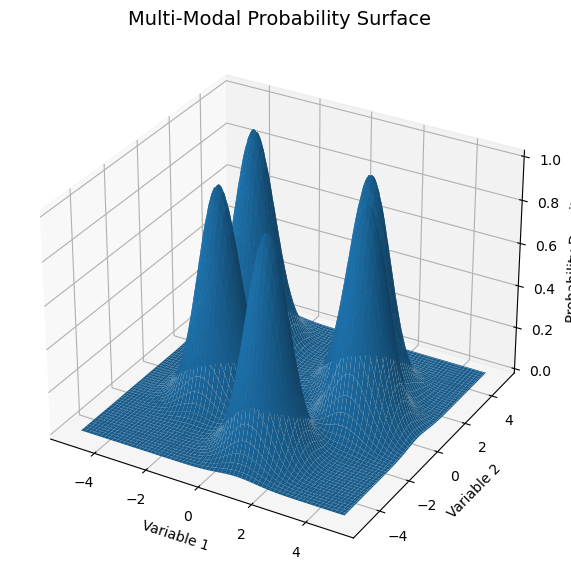

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # ensures 3D projection is registered

# 1. Grid 만들기
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

# 2. 여러 개의 Gaussian 봉우리 정의 (당신이 선택한 좌표 그대로)
Z = (
    np.exp(-((X - 2)**2 + (Y - 2)**2)) +
    np.exp(-((X + 2)**2 + (Y + 1)**2)) +
    np.exp(-((X - 1)**2 + (Y + 3)**2)) +
    np.exp(-((X + 3)**2 + (Y - 3)**2)) +
    np.exp(-((X - 3)**2 + (Y + 0)**2))
)

# 3. 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, rstride=3, cstride=3, linewidth=0, antialiased=True)

# 4. 축 라벨 & 제목
ax.set_title("Multi-Modal Probability Surface", fontsize=14)
ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.set_zlabel("Probability Density")

plt.show()


## 2. Variational Inference 접근의 기본 개요

Variational Inference는 이런 면을 해결할 수 있는, 즉 연산 비효율성을 해결할 수 있는 후보 중 하나입니다. VI는 전혀 다른 방법으로 목표 분포의 특징을 근사합니다. VI는 알 수 없는 복잡한 분포 (베이지안 통계에서는 사후 분포) 대신 내가 다루기 좋은 분포를 가져옵니다. 그걸 Q라고 하겠습니다. 목표 분포는 P라고 하죠. 그리고 Q를 최대한 P에 유사하게 만듭니다. 그리고 Q에서 정보를 가져와서, 이것이 P에 대한 정보라고 여깁니다. **즉 '내가 알고 싶은 분포가 너무 복잡해서 정보를 얻기 어려우니, 내가 다루기 쉬운 Q라는 분포를 최대한 P와 유사하게 조정하고, Q에서 얻은 정보를 P에서 얻은 정보라고 치자' 가 VI의 핵심적 발상입니다.** 

VI를 샘플링 기법 대신 사용하는 것을 샘플링 혹은 탐색(exploration)의 문제를 최적화 (optimization)의 문제로 전환하는 것이라고 표현하기도 합니다. 이건, P와 최대한 유사하도록 Q를 조정하는게 VI의 핵심인데, 'P와 Q의 최소 차이'를 찾아내는 걸 최적화라고 볼 수 있기 때문에 그렇습니다. 그리고 이런 방식은 매우 효율적인 경우가 많습니다. 사실 최적화 자체가 탐색보다 항상 연산 부담이 더 적은 것은 아닌데요, VI는 연산 효율화를 위해 여기서 일반적으로 한 가지 더 작업을 합니다. Q를 P보다 훨씬 단순하게 만들어 버리는 것입니다. P가 복잡한 이유는 그것이 다변수 함수이기 때문이었습니다. 게다가 대부분 변수 사이의 복잡한 의존성을 함수 형태로 표현하고 있지요. VI는 이를 단순화하기 위해 Q를 서로 독립인 여러 단변수 함수를 곱하는 형태를 갖추도록 하고, 그걸로 P를 근사합니다. 즉 P는 f(x,y) 였는데, f1(x)f2(y) 꼴로 만든 Q로 P와의 차이를 줄이는거죠. 그러면 연산이 좀 더 간단해집니다. 이걸 mean field approximation이라고 합니다. 

요약하자면,
1) P를 직접 탐색하는 대신 
2) 단순한 Q를 두고
3) Q와 P의 차이가 최소화되도록 만들어서 (최적화)
4) Q에서 P에 대한 정보를 얻는 
전략이라고 할 수 있습니다. 
이로 인해 계산이 (상대적으로) 단순해지고 연산이 빨라지는 경우가 많습니다. 

자 그러면 우리가 이 전략을 실행하기 위해서는 어떤 도구가 필요할까요? 크게 두 가지 카테고리의 도구들이 필요합니다. 
1. 분포 사이의 차이의 정도를 계량할 수 있는 도구, 즉 Q와 P의 차이를 계량할 수 있는 도구입니다. 
2. 그 계량된 차이를 체계적으로 감소시킬 수 있는 도구, 즉 이 계량값에 따라 Q를 점점 더 P에 가깝게 만드는 최적화 절차입니다. 

첫 번째는 KL-Divergence라는 지표가, 두 번째는 ELBO (evidence lower bound)라는 개념과 CAVI (Coordinate Ascent Variational Inference) 이라는 알고리즘이 담당합니다. 즉 KL-Divergence는 무엇이 좋은 Q인지 알려주고, ELBO와 CAVI는 좋은 Q를 찾아가는 방법을 알려주는 도구이지요. 나머지 수업 시간에는 이 두 가지 카테고리의 도구들에 대해 간단히 배우고, 그것을 LDA의 상황에 적용시켰을 때 어떤 형태가 되는지 살펴볼 것입니다. 

## 3. KL-Divergence

### 3.1. KL-Divergence의 직관적 의미

KL-divergence는 앞서 말한 것처럼 두 분포 사이의 차이의 정도를 측정하는 도구입니다. 일단 수식부터 알아보죠. P와 Q의 차이, 즉 KL-divergence는 아래와 같이 정의됩니다. 

$$
\begin{aligned}
D_{KL}(P||Q) &= \sum_{x}P(x)log(\frac{P(x)}{Q(x)})
\end{aligned}
$$

자 이 수식을 살펴봅시다. 이게 분포 사이의 차이의 정도를 측정한다는 것인데, 왜 측정할 수 있을까요? 이 수식의 형태를 어디선가 보신 적이 있을 것입니다. 어디서 보셨나요? 그렇습니다. 앞서 네트워크 파트에서 배운 엔트로피(Entropy)와 아주 닮아있죠. 엔트로피에서 배웠던 관점을 사용해 보면, 결국 이 수식이 P(x)와 Q(x)의 log 비율의 기대값이라는 점을 이해하실 수 있을 것입니다. 즉 이 값은 $log(\frac{P(x)}{Q(x)})$라는 불확실한 값을, P(x)를 기준으로 삼아 기대값을 만든 결과입니다. 

P(x)와 Q(x)가 유사할 때와 그렇지 않을 때 이 값이 어떻게 움직일지 생각해보시면, 왜 이런 수식으로 분포 간 차이를 측정하는지 이해하실 수 있습니다. 우선 둘이 유사한 경우를 생각해봅시다. P(x)와 Q(x)가 유사하다는 말은, 어떤 x를 넣든 비슷한 값을 출력한다는 말입니다. 그럼 $log(\frac{P(x)}{Q(x)})$은 어떻게 될까요? log 안에 1에 가까운 값이 들어갈테니, 0에 가까운 값이 나오겠죠. 여러 종류의 x 값에서 모두 0에 가까운 값을 출력하면 기대값도 당연히 0에 가까울 것입니다. 즉 P(x)와 Q(x)가 매우 유사할 때, 그래서 여러 x에 대해 비슷한 출력을 줄 때, KL-divergence는 0에 가까운 값을 가지게 됩니다. 

반대로 P(x)와 Q(x)가 서로 크게 다를 때는 어떨까요? 그럼 $log(\frac{P(x)}{Q(x)})$이 0에서 멀어집니다. P(x)의 출력이 Q(x)의 출력보다 커지는 방향으로 둘이 다르면 $log(\frac{P(x)}{Q(x)})$는 0보다 큰 값이 나오죠. 예를 들어 P는 x가 4일 값이 0.9라고 생각하는데 Q는 x가 4일 값이 0.01이라고 생각하면, $log{90}$가 되어서 4.5 정도의 값이 되겠네요. 거꾸로 P(x)의 출력이 Q(x)의 출력보다 작아지는 방향으로 둘이 다르면 $log(\frac{P(x)}{Q(x)})$는 0보다 작은 값이 나올 것입니다. 예를 들어 P는 x가 4일 값이 0.01라고 생각하는데 Q는 x가 4일 값이 0.9이라고 생각하면 $log{\frac{0.01}{0.9}}$가 되고 그래서 -4.5 정도의 값이 될 것입니다. 어느 경우건 0과 멀어지게 되죠. 

이렇게 $log(\frac{P(x)}{Q(x)})$이 0에서 많이 멀어지는 값들을 출력하게 되면, 이 불확실한 값들의 기대값은 0보다 커지게 됩니다. 0보다 작은 값들도 나올 수 있으니 0에 가깝게 나와야 하는게 아니냐고요? 그렇지 않습니다. 왜냐하면 P(x)를 기준으로 기대값을 만들기 때문입니다. P(x)를 기준으로 기대값을 만든다는 말은, 여러 불확실한 값이 출현할 가중치를 P(x)를 기준으로 주겠다는 말입니다. 예를 들어 우리가 어떤 불확실한 값의 기대값을 산출한다고 하고, 그 불확실한 값이 6과 -6 두 개의 가능성을 가진다고 하죠. 전자의 가능성은 90%, 후자의 가능성은 10%라고 합시다. 그러면 $-6 \times 0.1 + 6 \times 0.9$로 계산을 해서 4.8의 결과를 냅니다. 두 가능한 값 자체는 대칭적이지만, 가능성은 대칭적이지 않고, 그것을 고려해서 0보다 크게 기대값이 나오는거죠. P를 기준으로 기대값을 만들 때도 비슷한 일이 생깁니다. $log(\frac{P(x)}{Q(x)})$는 0보다 작을 수도 있고 클 수도 있습니다. $\frac{P(x)}{Q(x)}$에서 P가 Q보다 클 수도 있고, Q가 P보다 클 수도 있기 때문입니다. 하지만 이걸 P를 기준으로 기대값을 취하면, P가 Q보다 큰 경우를 더 중요하게 취급합니다. 왜냐하면 그때 P가 크니까요. P가 클 때 만들어진 $log(\frac{P(x)}{Q(x)})$이 출현 가능성이 더 크다고 본다는 말입니다. 그러니 결과적으로 기대값은 0보다 크거나 같게 됩니다. 

요컨대 P(x)과 Q(x)가 유사하면 KL-divergence는 0에 가까운 값이 나옵니다. log안에 1과 유사한 값이 들어가게 되기 때문입니다. 반대로 P(x)과 Q(x)가 다르면, 0보다 큰 값이 나옵니다. 차이가 나게 되면 1과 다른 값이 log에 들어가게 되고, 특히 1보다 큰 값이 들어갈 경우가 (P(x)가 Q(x)보다 더 큰 경우) 중요하게 여겨지기 때문입니다. 그렇기에 KL-divergence는 두 분포 사이의 차이의 정도를 측정하는 값이 될 수 있습니다. 이것은 0을 최소값으로 가지고, 그 값이 커지면 커질수록 두 분포가 차이를 보임을 뜻합니다. 

다만 제가 지금껏 말씀드린 KL-divergence 값의 범위에 대한 설명은 다소 직관적인 면이 있습니다. 이에 대한 일종의 증명이나 보다 엄밀한 설명이 필요하시다면, 아래 <3.2. KL-Divergence 범위에 대한 추가 설명>절을 참조하시기 바랍니다. KL-divergence를 이루는 개별항인 $log(\frac{P(x)}{Q(x)})$는 x값에 따라 음수가 될 수 있지만 기대값 전체는 **음수가 될 수 없다**는 점을 보이는 것은 그리 어렵지 않게 가능합니다. **로그 함수가 오목(concave) 하다는 성질**과 그에 따라 성립하는 **얀센의 부등식 (Jensen's inequality)** 을 활용하면 됩니다. 필요하시지 않은 분은 바로 3.3절로 넘어가셔도 상관없습니다만, 혹시 이에 대한 좀 더 자세한 설명이 필요하시면 3.2절로 가봅시다. 

### 3.2. KL-Divergence 범위에 대한 추가 설명

일단 아주 간단한 사실에서 출발합시다. 아래와 같은 부등식이 성립합니다. 

$$
\begin{gathered}
\log{t} <= t-1
\end{gathered}
$$

왜냐고요? 그림보면 당연히 그렇게 나옵니다. 

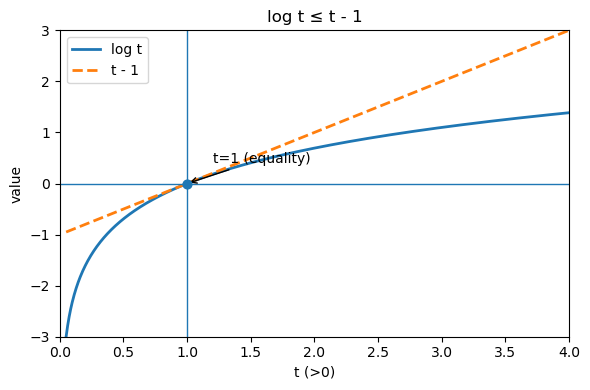

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# t>0 범위에서 살펴봄
t = np.linspace(0.05, 4.0, 1000)
y_log = np.log(t)
y_tangent = t - 1  # t=1에서의 접선

plt.figure(figsize=(6,4))
plt.plot(t, y_log, label='log t', linewidth=2)
plt.plot(t, y_tangent, label='t - 1', linestyle='--', linewidth=2)

# t=1 표식(등호가 성립하는 지점)
plt.scatter([1],[0], s=40, zorder=5)
plt.annotate('t=1 (equality)', xy=(1,0), xytext=(1.2,0.4),
             arrowprops=dict(arrowstyle='->', lw=1))

plt.axhline(0, linewidth=1)
plt.axvline(1, linewidth=1)

plt.xlim(0,4)
plt.ylim(-3,3)
plt.xlabel('t (>0)')
plt.ylabel('value')
plt.title('log t ≤ t - 1')
plt.legend()
plt.tight_layout()
plt.show()


일단 그림 차원에서 $\log{t} <= t-1$를 납득하셨다면, t 대신에 $\frac{Q(x)}{P(x)}$를 넣어봅시다. 그러면 아래와 같이 전개 되죠. 

$$
\begin{aligned}
\log{\frac{Q(x)}{P(x)}} &\le \frac{Q(x)}{P(x)} - 1 \\
P(x)\log{\frac{Q(x)}{P(x)}} &\le Q(x) - P(x) \\
\sum_{x}P(x)\log{\frac{Q(x)}{P(x)}} &\le \sum_{x}Q(x) - \sum_{x}P(x) \\
\sum_{x}P(x)\log{\frac{Q(x)}{P(x)}} &\le 0 \\
\sum_{x}P(x)\log{\frac{P(x)}{Q(x)}} &\ge 0 \\
D_{KL}(P||Q) &\ge 0
\end{aligned}
$$



즉 KL-Divergence는 항상 양일 수 밖에 없습니다. 이걸 얀센의 부등식을 써서 증명할 수도 있습니다. 일단 얀센의 부등식은 다음과 같습니다. 

1. 함수 f가 볼록 (convex) 하면, 즉 컵처럼 아래로 튀어나와 있으면, $f(E(X)) \le E(f(X))$
2. 함수 f가 오목 (concave) 하면, 즉 뒤집어놓은 컵처럼 위로 튀어나와 있으면, $f(E(X)) \ge E(f(X))$

그런데 로그는 오목합니다. 위가 튀어나왔죠. 저 위에 그림의 파란 선만 보셔도 그것을 쉽게 아실 수 있습니다. 그러면 여기서 이 부등식을 KL-divergence와 연결할 수 있습니다. 일단 f를 로그 함수라고 치면, 아래와 같은 부등식이 성립하죠. 

$$
\log(E(X)) \ge E(\log(X))
$$


그런데 우리의 관심사인 $D_{KL}(P||Q)$는 $\sum_{x}P(x)\log{\frac{P(x)}{Q(x)}}$ 꼴이었습니다. 이건, $\frac{P(x)}{Q(x)}$를 로그를 적용해서 P라는 분포를 활용해 기대값을 취하는 형태죠. 지금 우리가 만든 수식 우변에 딱 맞습니다. X를 $\frac{P(x)}{Q(x)}$라고 넣으면 딱 맞죠. 그런데 우리는 이것의 하한을 구하고 싶은거잖아요? 그래서 의도적으로 거꾸로 뒤집어서 넣습니다. 즉 X를 $\frac{Q(x)}{P(x)}$로 넣고, 마이너스를 유도해서 부등호를 뒤집는거죠. 아래처럼 말이죠. 

$$
\begin{aligned}
\log(E_P(\frac{Q(x)}{P(x)})) &\ge E_P(\log(\frac{Q(x)}{P(x)})) \\[15pt]
\log(E_P(\frac{Q(x)}{P(x)})) &\ge - E_P(\log(\frac{P(x)}{Q(x)})) \\[15pt]
-\log(E_P(\frac{Q(x)}{P(x)})) &\le E_P(\log(\frac{P(x)}{Q(x)})) \\[15pt]
-\log(E_P(\frac{Q(x)}{P(x)})) &\le D_{KL}(P||Q)
\end{aligned}
$$

자 이까지 따라오기 어렵지 않으시죠? 근데 이제 좌변을 뜯어봅시다. 저건 뭔가요?저건 0입니다. 왜냐하면 $E_P(\frac{Q(x)}{P(x)})$이 1이기 때문입니다. 아래를 보죠. 

$$
\begin{aligned}
E_P(\frac{Q(x)}{P(x)}) &= \sum_{x}P(x)\frac{Q(x)}{P(x)}\\[15pt]
&= \sum_{x}Q(x)\\[15pt]
&= 1
\end{aligned}
$$

P(x)든 Q(x)든 다 확률 분포 함수이니, 모든 support에 대해 합치면 1이 되는 성질을 가지니 이렇게 되죠. 그러면 최종적으로 어떻게 되나요?

$$
\begin{aligned}
-\log(E_P(\frac{Q(x)}{P(x)})) &\le D_{KL}(P||Q) \\[15pt]
-\log(1) &\le D_{KL}(P||Q) \\[15pt]
0 &\le D_{KL}(P||Q) \\[15pt]
D_{KL}(P||Q) &\ge 0
\end{aligned}
$$

동일한 방식으로, KL-divergence는 항상 0 이상임이 증명됩니다. 두 분포가 완전일치할 때 0, 그리고 분포간 차이가 커지면 점점 커지는거죠. 

참고로 얀센의 부등식이 왜 말이 되는지 알아봅시다. 말로하자면, 어떤 오목한 함수가 있을 때, 애초에 입력값을 평균내서 그 함수를 통과시켰을 때가, 입력값들을 매우 함수에 통과시켜서 평균 낸거보다 항상 크거나 같다는 말이죠. $f(E(X)) \ge E(f(X))$ 이 수식으로 표현되었습니다. 간단히 상상해봅시다. 아래와 같은 $y = -x^2 + 5$ 같은 수식의 그래프를 봅시다. 

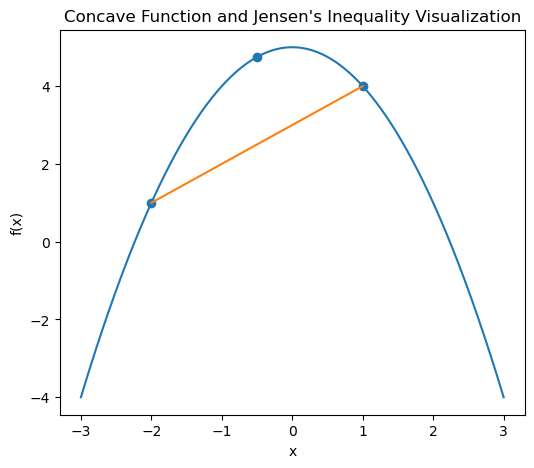

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define the concave function
def f(x):
    return -x**2 + 5

# x range for curve
x = np.linspace(-3, 3, 400)
y = f(x)

# Two example points
x1, x2 = -2, 1
y1, y2 = f(x1), f(x2)

# Midpoint
xm = (x1 + x2) / 2
ym = f(xm)

# Coordinates for chord (line segment)
line_x = np.array([x1, x2])
line_y = np.array([y1, y2])

# Plot
plt.figure(figsize=(6,5))
plt.plot(x, y)  # curve
plt.plot(line_x, line_y)  # straight line between points
plt.scatter([x1, x2, xm], [y1, y2, ym])  # mark the points
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Concave Function and Jensen's Inequality Visualization")
plt.show()


자 얀센의 부등식을 단순화하자면, -2라는 입력값과 1라는 입력값을 함수에 통과시켜서 그것의 평균을 구한것보다, 애초에 -2와 1을 평균 내서 함수를 통과시킨 값이 클 수 밖에 없다는 말입니다. 실제로 그렇죠. -2와 1의 평균은 -0.5입니다. 그게 지금 목표 함수에 들어가면, 4.75입니다. 근데 둘을 먼저 통과시켜 평균내면, (1+4)/2니까, 2.5네요. 이건 가운데가 오목하고 올라가 있으니 그럴 수 밖에 없습니다. 

이야기가 좀 돌았는데, 핵심은 KL-divergence는 항상 0보다 크거나 같을 수 밖에 없습니다. 얀센의 부등식을 통해 이를 증명할 수 있습니다. 0과 같을 때에는 두 분포가 완전히 같음을 의미하고, 값이 클 수록 차이가 크다고 말할 수 있습니다. 

### 3.3. KL-divergence의 비대칭성

한 가지 또 주목해야 할 중요한 지점이 있습니다. 그건 KL-divergence가 대칭적이지 않다는 점입니다. 즉 $D_{KL}(P||Q) \neq D_{KL}(Q||P)$ 입니다. 이건 기대값을 취할 때 P의 관점에서 취하냐 Q의 관점에서 취하냐가 달라서 그렇습니다. $D_{KL}(P||Q)$과 $D_{KL}(Q||P)$를 각각 적어봅시다. 

$$
\begin{aligned}
D_{KL}(P||Q) &= \sum_{x}P(x)log(\frac{P(x)}{Q(x)})\\[15pt]
D_{KL}(Q||P) &= \sum_{x}Q(x)log(\frac{Q(x)}{P(x)})
\end{aligned}
$$

다시 한 번 직관적으로 설명해보면, $D_{KL}(P||Q)$는 말하자면 P의 관점에서 Q의 값이 얼마나 이상한지 보는 것입니다. 이 값은 언제 커지나요? P(x)의 출력이 커지는 구체적인 입력 x'에서, Q(x')와 P(x')의 값이 매우 달라야 합니다. 그것은 P가 중요하게 보는 값에서 P와 Q의 출력값이 다르다는 뜻입니다. 그러니 **P의 관점에서 보는 둘 사이의 차이**라고 정의할 만한 수치인 것이지요. 거꾸로 P가 중요하게 보지 않는 값에서 Q가 어떤 값을 보이건 크게 개의치 않습니다. 예를 들어 x''라는 값은 P에서는 중요하게 보지 않는다고, 출현 개연성이 매우 낮다고, 즉 P(x'')가 매우 낮다고 생각해보죠. 이 경우 Q(x'')커 커도, 전체 값에 영향이 별로 없습니다. 결국 둘의 비율에 로그값이 붙인 이후, P(x'')를 가중치로 삼아서 기대값에 기여하게 되니까요. 

그런데 거꾸로 Q의 관점에서 보면 어떻게 될까요? Q(x)와 P(x)의 차이를 보기 위해 구하는 둘 사이의 비는 분모 분자만 바뀐 형태이지만, 이것이 Q의 관점에서 가중 평균, 즉 기대값 계산이 일어납니다. 둘 사이의 차이/비도 중요하지만, Q가 그 값이 만들어진 구체적인 x'값이 얼마나 자주 출현할 것이라고 판단하는 것도 중요합니다. 애초에 Q가 그 값은 별로 일어날 일이 없다고 보면, 즉 Q(x')이 작으면, 둘 사이의 차이가 커도 기대값에 기여를 하지 않게 됩니다. 그렇기에 동일한 P(x)와 Q(x)를 가지고도, $D_{KL}(P||Q) \neq D_{KL}(Q||P)$가 성립하게 됩니다. 기준이 되는 분포가 달라지면, 차이에 대한 판단도 달라지기 때문입니다. 

요컨대 두 분포의 차이의 정도를 측정할 때에는 '어떤 분포의 관점에서 보느냐'가 중요합니다. 기대값이라는 것은 결국 어떤 불확실한 값이 있을때, 그 개연성을 고려해서 내는 가중 평균입니다. 그리고 KL-divergence에서는 이 개연성을 판단하는 분포를 둘 중 하나로 선정하게 됩니다. 즉 $D_{KL}(P||Q)$와 $D_{KL}(Q||P)$는 그냥 순서만 뒤집힌 것이 아니라, 어떤 분포를 기준으로 볼 것이냐, 기대값 산출할 때 가중치가 되는 개연성을 어디서 가져올 것이냐라는 중대한 차이를 포함하게 됩니다. 그러니 둘은 자연히 달라집니다. 

KL-divergence가 정의하는 두 확률 분포의 차이의 정도는 관점 혹은 기준이 되는 분포에 따라 달라질 수 있습니다. 그래서 **KL-divergence는 특정 분포의 관점에서 다른 분포와의 차이의 정도를 계량하는 지표라고 해야 할 것입니다.**

## 4. ELBO

자 그러면 우리의 문제 상황으로 다시 돌아와봅시다. 우리는 P를 근사하고 싶습니다. 그리고 실제 이것은 베이지안 통계에서 나온 사후 분포입니다. P(Z|x)라고 놓는 것이 적절할 거 같습니다. x는 데이터라고 생각하고요. Q(Z)는 이 P(Z|x)에 붙이려는 우리가 다루기 쉬운 분포입니다. 그러면, 이걸 뭘 기준으로 놓고 KL-divergence를 보면 좋을까요?

기본적으로 이런 상황에서는 Q를 기준으로 합니다. 즉 $D_{KL}(Q(Z)||P(Z|x))$를 계산하려 한다는 말입니다. 사실 두 분포를 붙여야 하기에 어느 쪽이든 진행이 이론적으로 가능할 것입니다. 그런데, 우리가 애초에 이 일을 왜 하고 있는지 상기해봅시다. P(Z|x)가 복잡해서 이걸 하고 있습니다. 복잡해서 왜 문제였죠? 거기서 수리적/해석적으로 정보를 뽑기 어려워서 그랬습니다. 그런데 지금  $D_{KL}(P(Z|x)||Q(Z))$를 구하려면 P(Z|x)에 의한한 값을 곱해서 가중평균해야 합니다. 우리가 하기 싫었고 하기 힘들었던 일을 여기서 해야 하는 것입니다. 반면  $D_{KL}(Q(Z)||P(Z|x))$는 Q(Z)의 입장에서 기대값을 구하게 되고, Q는 우리가 가정한 것이라는 점에서 계산을 간단하게 할 가능성이 열려 있습니다. 그러니 $D_{KL}(Q(Z)||P(Z|x))$를 최소화하는 방식으로 문제를 설정합니다. 

그 다음으로 $D_{KL}(Q(Z)||P(Z|x))$를 최소화하는 문제를 ELBO (Evidence Lower Bound)를 최대화하는 문제로 바꿉니다. 우선 ELBO가 뭔지 알기 위해 아래 유도를 봅시다. 

$$
\begin{aligned}
(1) \quad D_{KL}(Q(Z)||P(Z|x)) &= \sum_{z}Q(z)log(\frac{Q(z)}{P(z|x)}) \\[15pt]
(2) \quad D_{KL}(Q(Z)||P(Z|x)) &= E_Q(\log{Q(z)}) - E_Q(\log{P(z|x)}) \\[15pt]
(3) \quad D_{KL}(Q(Z)||P(Z|x)) &= E_Q(\log{Q(z)}) - E_Q(\log{P(z,x)}) + log{P(x)} \\[15pt]
(4) \quad D_{KL}(Q(Z)||P(Z|x)) &= log{P(x)} - [E_Q(\log{P(z,x)}) - E_Q(\log{Q(z)})] 
\end{aligned}
$$

유도는 간단합니다. (1)은 KL-divergence 공식을 표현한 것입니다. (2)로 가는 것은 로그에 있는 분수를 로그들의 빼기로 전환하여, 각각 Q 관점에서 기대값으로 만들 수 있기 때문입니다. 즉 $log\frac{Q(z)}{P(z|x)}$를 $log{Q(z)} - log{P(z|x)}$로 만들 수 있으니, 그것에 각각 $Q(z)$를 붙여서 기대값으로 만든거죠. (2)에서 (3)으로 가는 것은, 조건부 확률 공식을 활용하여 $P(z|x) = \frac{P(z,x)}{P(x)}$ 이렇게 전개한 후 정리한 것입니다. 왜 logP(x)가 기대값 바깥으로 나온 것일까요? logP(x)가 z와 아무 상관이 없고, 그렇기에 Q(z)라는 'z'의 불확실성의 구조를 표현하는 함수 관점에서 logP(x)는 그냥 상수이기 때문입니다. 그러니 기대값 공식을 그냥 빠져 나온 것이지요. (4)는 (3)을 보기 좋게 정리한 것입니다.  

여기서 다시 한 번 주목해야 할 사항이 $log{P(x)}$는 Q(z)에 따라 변동하는 값이 아니라는 점입니다. 그런데 궁극적으로 우리 목표가 뭔가요? 그것은 **Q(Z)를 조정해서 P(Z|x)와 유사하게 만드는** 겁니다. 그런데 그 관점에서 $log{P(x)}$는 그냥 상수죠. 아무리 Q(z)를 조정해봐야, 변하지 않는 값이라는 말입니다. 그렇다면, $D_{KL}(Q(Z)||P(Z|x))$가 작아지려면 어떻게 해야 할까요? 그러려면 (4)에서 대괄호 안에 있는 $E_Q(\log{P(z,x)}) - E_Q(\log{Q(z)})$가 최대한 커져야 합니다. 정리하자면 (4)의 구도가 '상수' - '대괄호' 로 되어 있는 셈인데, 이 값이 작아지려면 대괄호 파트가 최대한 커져야 합니다. 이 대괄호 부분을 ELBO라고 합니다. 이게 최대한 커질 때, $D_{KL}(Q(Z)||P(Z|x))$가 최소가 됩니다. 그러면 **$D_{KL}(Q(Z)||P(Z|x))$ 최소화하는 문제는 ELBO를 최대화하는 문제와 동일합니다.** 이렇게 문제를 전환할 수 있습니다. 

그런데 굳이 이렇게 전환을 하는 이유가 뭔가요? 그건 P(x) 파트가 P(Z|x)를 복잡하게 만드는 핵심 요인이었기 때문입니다. 그걸 계산 과정에서 배제하고 싶은거죠. 계속 반복하지만, 굳이 VI니 샘플링이니 하는걸 동원하는 이유는 P(Z|x), 즉 데이터가 주어졌을 때 우리의 관심 파라미터들의 사후 분포가 복잡하기 때문입니다. 베이즈 정리에 따라 이 P(Z|x)는 어떻게 주어졌나요? 아래와 같이 주어졌습니다. 

$$
\begin{gathered}
P(Z|x) = \frac{P(x|Z) \times P(Z)}{P(x)}
\end{gathered}
$$

앞서 6장에서 우리는 LDA에서 이 전개가 구체적으로 어떻게 펼쳐지는지도 봤습니다. 상기해보자면 아래와 같았습니다. 

$$
\begin{gathered}
P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}|W_{1:D, 1:N}, \alpha, \eta) \\[20pt]
= \frac{P(W_{1:D, 1:N}| \theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K} | \alpha, \eta)}{P(W_{1:D, 1:N})}\\[20pt]
=\frac{\prod_{k=1}^KP(\beta_k|\eta)\prod_{d=1}^D[P(\theta_d|\alpha)\prod_{n=1}^{N_d}P(Z_{d,n}|\theta_d)P(W_{d,n}|\beta_{Z_{d,n}})]}{\int_{\beta}\int_{\theta}\sum_{Z}\prod_{k=1}^KP(\beta_k|\eta)\prod_{d=1}^D[P(\theta_d|\alpha)\prod_{n=1}^{N_d}P(Z_{d,n}|\theta_d)P(W_{d,n}|\beta_{Z_{d,n}})]}
\end{gathered}
$$


휴우 다시 봐도 짜증나네요 ㅎㅎ 그런데 여기서 복잡한게 분자 부분도 있지만, 진짜 아예 접근을 불허하도록 복잡했던게 분모 부분입니다. 즉 Evidence 부분이죠. 다시 말하지만, 이건 가능한 모든 관심 파라미터 조합에서 지금 주어진 데이터가 출현할 확률을 다 더한 것이기에 복잡할 수 밖에 없습니다. 절반 정도는 Evidence 파트 때문에 근사 기법인 샘플링이나 VI를 고려했던 것입니다. 

그런데, VI를 진행하는데 또 P(x)가 나온 것입니다. 이건 P(Z|x)를 다루고 있는 한 어쩔 수 없습니다. 그런데, KL-divergence 최소화 문제를 ELBO 최대화 문제로 전환하면, 이 P(x)를 신경쓰지 않는 구도로 만들 수 있습니다. 이것이 바로 ELBO가 도입된 이유입니다. P(x)와 무관하게 Q(Z)의 형태를 조정할 기준을 제공하고 있기 때문입니다. 

즉 **ELBO가 도입되는 까닭은 P(x)를 직접 계산하지 않고도 Q(Z)를 P(Z|x)와 유사하게 만드는 최적화 문제를 설정할 수 있기 때문입니다.** MCMC에서는 상대적 빈도에 집중하면서 이 정규화 상수 파트인 Evidence를 고려하지 않는 방안을 고안했죠. VI에서는 ELBO가 그 역할을 하고 있습니다. 어느 쪽 근사 기법이건 복잡한 분포 함수라는 상황을 극복해야 하는데, 각자 다른 방법으로 P(x) 파트를 해결하고 있는 셈입니다. 그리고 ELBO는 복잡한 사후 분포를 직접 다루지 않고도 해당 분포에 근접한 Q(Z)를 찾도록 해주는 **계산 가능한 최적화 기준** 역할을 하는 것이지요. 

## 5. Mean-Field Approximation

자 여기서 한 번 더 계산 가능성을 위한 조치를 해봅시다. 그게 바로 Mean-field approximation입니다. 이번에는 P(Z|x)를 복잡하게 만들었던 '분자' 부분에 주목합니다. 사후 분포가 복잡한 요인 중 가장 중요한 부분은 Evidence 파트일 것입니다. 즉 사후 분포의 분모 파트죠. 하지만 분자 파트도 만만치 않습니다. 사후 분포를 구성하는 여러 변수들이 서로 복잡한 의존 관계를 맺기 때문에 왔습니다. Evidence는 ELBO로 우회하였지만, 여러 변수가 서로 의존 관계를 맺고 있어서 분포식 자체가 복잡하다는 건 여전히 남아 있죠. 여기서 VI는 통상 한 번 더 단순화를 시도합니다. 목표 분포인 다변수 함수, 즉 여러 변수의 결합 확률 분포를 표현하고 있는 이 함수를, 여러 단변수 함수의 곱으로 근사하는 것입니다. 

수식이 오히려 이해가 쉬우실 듯한데, 아래를 봅시다. 우리는 그냥 잠재 변수 전체를 $Z$라고 썼지만, 사실 이것은 그냥 목표를 표현한 것일 뿐, 실제로는 $z_1, z_2, z_3...$ 등등이 있습니다. LDA에서도 그랬죠. 토픽, 문서별 토픽 분포, 단어별 토픽 할당이 그것들이었습니다. 그냥 종류별로 적어도 세 개고, 이걸 실제로 진짜 변동하는 값들마다 따로 변수화해서 쓰면 끝도 없을 것입니다. (토픽 개수만큼, 문서 갯수만큼, 단어 갯수만큼 기호가 필요하겠네요) 요컨대

$$
\begin{gathered}
P(Z|x) = P(z_1, z_2, z_3,....|x)
\end{gathered}
$$

인 셈이죠. 그리고 원칙적으로 이걸 근사하려면 Q(Z)도 그런 결합 분포 꼴이어야 합니다. 즉 아래와 같아야 합니다. 

$$
\begin{gathered}
Q(Z) = Q(z_1, z_2, z_3,....)
\end{gathered}
$$

그런데 이걸 아래와 같이 바꿔 버리는 것입니다. 

$$
\begin{gathered}
Q(Z) = q_1(z_1)q_2(z_2).... = \prod_i q_i(z_i)
\end{gathered}
$$

이것은 잠재변수들이 서로 독립했다고 가정하는 것입니다. 사실 의존이 존재할 수 있지만, 의도적으로 단순화하는 것입니다. 이렇게 하면 연산이 단순해지는 효과가 있습니다. 그렇다고 이걸 그냥 '우기는' 과정이라고 볼 수는 없습니다. 일단 다변수들이 의존을 통째로 고려하면, 우리가 탐색해야 할 분포의 공간이, 그러니까 분포가 가질 수 있는 가능성의 공간이 너무 넓습니다. 계산이 늘어날 수 밖에 없죠. 그런데 이걸 모델링하는 과정에서 (모든 모델의 핵심은 단순화죠) 우리의 탐색 공간을 개별 변수 분포들의 곱으로 만들어지는 공간으로 한정해 버리는 것입니다. 즉 탐색 공간을 한정하고, 그 제한 조건 안에서 목표 분포와 가장 비슷한 Q(Z)를 찾는 것입니다. 

많은 상황에서 이건 아주 유효합니다. 많은 경우 이러한 단순화에도 불구하고, 개별 잠재 변수 분포에 대한 중요 정보는 비교적 잘 보존된다고 합니다. 그리고 잠재 변수들 간의 정보가 완전히 사라지는 것은 아닙니다. 이어질 다음 장에서 보겠지만, 이렇게 하더라도 개별 잠재변수를 업데이트할 때, 나머지 잠재변수들의 '기대값'이 그 업데이트에 관여하게 됩니다. 즉 '기대값'을 통한 간접적 영향은 여전히 남아 있게 되는거죠. 그렇기에 실제 여러 상황에서 이런 근사는 아주 잘 작동하곤 합니다. 

## 6. Coordinate Ascent Variational Inference (CAVI)

자 거의 다 왔습니다. 우리는 P(Z|x)를 근사하기 위해, Q(Z)를 그것과 유사하게 만들려고 합니다. 이를 위해 이제까지 

1. '유사성'을 계량할 수 있는 KL-divergence를 배웠고, 
2. 그것을 최소화하는 과정에서 Evidence를 우회하는 기법인 ELBO를 배웠고, 
3. 목표 분포에 근접시킬 Q(Z)를 설정하는 노하우인 Mean-field approximation을 배웠습니다. 

이제 남은 것은 $P(Z|x)$, 즉 $P(z_1, z_2, z_3,....|x)$와 유사해지도록 $Q(Z)$를, 정확히 말해 $q(z_1)q(z_2).... = \prod_i q_i(z_i)$를 조정하는 것입니다. 그런데 이걸 구체적으로 어떻게 하느냐? 여기서 Coordinate Ascent Variational Inference (CAVI) 라는 전략이 등장합니다. 

이 전략은 $q_i(z_i)$들을 한꺼번에 조정하는 것이 아니라, 하나하나 조정해가면서 전체적으로 조정하는 접근을 의미합니다. 즉 $Q(Z)$가 $\prod_i q_i(z_i)$로 정의되었으니, 그 항목 하나하나를 순차적으로 조정합니다. 하나를 조정할 때에 다른 파트는 고정합니다. 하나의 분포만 조정될 수 있는 상태라고 생각하고 나머지 분포들은 파라미터를 현재 상태로 고정하는거죠 (이 현재 상태란 처음에는 여러 방식으로 선정된 초기값이 될 것이고, 나중에는 현재 추정값이 될 것입니다). 

요컨대 $q_i(z_i)$들을 $Q(Z)$를 이루는 여러 축이라고 했을 때, 하나의 축을 조정하고 (나머지 축은 고정), 그 다음 축을 조정하고, 이런 식으로 진행하겠다는 것입니다. 그래서 이걸 Coordinate Ascent Variational Inference, 말 그대로 한 축 씩 조정해가면서 여러 축을 조정해 상승해 가는 방식이라고 부르는 거죠. 

자 그러면 우리는 $q_1(z_1), q_2(z_2), q_3(z_3)...$ 등을 단계적으로 조정해야 합니다. 그럼 조정의 기준은 뭔가요? 말했듯이 그건 ELBO 입니다. 다만 이때 Q 전체를 조정해서 ELBO를 상승시키는게 아니라 $q_i$를 순차적으로 조정해서 ELBO를 조정해야죠. 그러면 우리는 $ELBO(Q)$ 대신 $ELBO(q_i)$를 구해야 합니다. 정확히는 $ELBO(q_i|q_{-i})$를 구해야 합니다. 즉, 하나의 $q_i$ 빼고는 다 조건으로 주어진 상태에서 (즉 파라미터가 현재값으로 고정된 상태에서) $q_i$에 따른 ELBO의 움직임을 표현하는거죠. 즉 ELBO를 $q_i$에 대한 함수로 보이도록 재표현하는 것입니다. 그런 다음, $ELBO(q_i|q_{-i})$가 가장 커지는 방향으로 $q_i$를 조정하고, 이를 순차적으로 반복하는 것입니다. 

그러므로 우리는 $ELBO(q_i|q_{-i})$의 형태로 ELBO를 표현해야 합니다. 물론 이를 위해서는 $q_i$라는 분포는 변동 가능한 반면, 그 이외의 분포 파트들, 즉 $q_{-i}$는 어떻게든 형태가 고정되어 있다는 가정도 함께 들어가야 합니다. 자 어떻게 ELBO를 변형하면 좋을까요? 일단 ELBO를 다시 한 번 살펴봅시다.  

$$
\begin{gathered}
ELBO(Q) = E_Q(\log{P(Z,x)}) - E_Q(\log{Q(z)})
\end{gathered}
$$

여기서 $q_i$와 $q_{-i}$를 분리해서 정리하는 일이 필요합니다. 그래야 후자는 고정되어 있는 상태라고 가정하여 성질을 규정하고, 전자에 대한 함수로 ELBO를 표현할 수 있기 때문입니다. 이를 위해서는 Q(Z)를 $\prod_i q_i(z_i)$로 풀어서 표현한 후, $q_i$ 파트와 그 이외의 파트를 ELBO 표현에서 따로 분리시켜줘야 할 것입니다. 첫 번째 항인 $E_Q(\log{P(Z,x)})$와 두 번째 항인 $E_Q(\log{Q(Z)})$를 각자 정리해봅시다. 

첫 번째 항 $E_Q(\log{P(Z,x)})$ 은 어떻게 변형될까요? 기본적으로 아래와 같습니다. 

$$
\begin{aligned}
E_Q(\log{P(Z,x)}) &= \sum_z Q(Z)logP(x,Z) \\[15pt]
&= \sum_{z_i} q_i(z_i)\sum_{z_{j \neq i}} (\prod_{j \neq i}q_j(z_j))logP(x,Z) \\[15pt]
&=\sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)]
\end{aligned}
$$


우선 첫 번째 등식은 기대값으로 표현된 것을 다시 풀어서 표현한 것이지요. 그 이후 두 번째 세 번째로 넘어가는 건, 식에서 $q_i(z_i)$만 따로 빼는 과정입니다. 이렇게 정리될 수 있는 것은, 벡터의 시그마를 여러 개의 스칼라 값의 시그마 중첩으로 표현할 수 있기 때문입니다. 그러니까 이런 셈입니다. 

$$
\begin{aligned}
\sum_z Q(Z)logP(x,Z) &= \sum_{z_1}\sum_{z_2}\sum_{z_3}\cdots Q(Z)\log P(x,Z)\\[15pt]
&=\sum_{z_1}\sum_{z_2}\sum_{z_3}\cdots \prod_i q_i(z_i) \log P(x,Z)\\[15pt]
&=\sum_{z_i} q_i(z_i)\sum_{z_{j \neq i}} (\prod_{j \neq i}q_j(z_j))logP(x,Z)\\[15pt]
&=\sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)]
\end{aligned}
$$


왜 벡터의 시그마를 저렇게 펼수 있는지 의아할 수도 있는데, 사실 단순한 조합의 원리입니다. 예를 들어 $Z = (z_1, z_2)$ 라는 형태의 벡터가 있고, 각 위치의 가능성이 {0,1,2} 셋 중 하나라고 하죠. 그러면 '모든 Z 값의 가능성'은 $z_1$을 0으로 고정하고, $z_2$를 0,1,2로 전환하면서 값을 계산하여 합치고, 그 다음 $z_1$을 1로 고정하고 $z_2$를 다시 0,1,2로 전환하면서 값을 계산해서 합치고, 마지막으로 $z_1$을 2로 고정하고 $z_2$를 0,1,2로 바꿔가며 값을 계산해서 합치면 됩니다. 그러면 9개의 가능성이 모두 계산되어 합쳐지죠. 이걸 그냥 $\sum_{z_1}$$\sum_{z_2}$라고 쓰는 것입니다. 

그런데 그렇게 쓰고 보면, 지금 변동시키려는 $q_i(z_i)$만 다른 스칼라 값을 통제하는 시그마 바깥으로 뺄 수 있게 됩니다. 그들 입장에서 $q_i(z_i)$는 상수니까요. 그런데 그렇게 빼고 보면, $\sum_{z_{j \neq i}}$ 부터 다음의 수식은 $q_i(z_i)$를 제외한 나머지 분포에 대한 기대값을 취한 꼴이 됩니다. 그래서 맨 아래 수식처럼 선언을 할 수 있게 되는거죠. 

그러면 이제 두 번째 항 $E_Q(\log{Q(z)})$도 조정해 봅시다. 일단 Q(Z) 자리에 mean-field approximation의 결과인 $\prod_i q_i(z_i)$를 넣고, 로그를 취하는 곱의 연쇄를 로그 더하기의 연쇄로 바꿔줍니다.  

$$
\begin{aligned}
E_Q[\log{Q(z)}] &= E_Q[\log{\prod_i q_i(z_i)}] \\
&= E_Q[\sum_i log(q_i(z_i))]
\end{aligned}
$$

이제 조정된 첫 번째와 두 번째 항을 붙여놓고 봅시다. 이걸 정리하면 어떻게 될까요? 아래와 같이 됩니다. 

$$
\begin{aligned}
&\sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - E_Q[\sum_i log(q_i(z_i))] \\[15pt]
&= \sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - E_{q_i}[log(q_i(z_i))] + \text{constant} \\[15pt]
&= \sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - \sum_{z_i} q_i(z_i) log(q_i(z_i)) + \text{constant}
\end{aligned}
$$

우선 두 번째 항이 두 번째 수식에서 $q_i$에 대한 기대값과 상수로 분리되는 파트를 눈여겨 보셔야 합니다. 자 일단 Q에 대한 기대값 함수 안에 더하기로 연결된 여러 파트가 존재합니다. 기대값 함수는 선형 함수의 성질을 가지기 때문에, 덧셈으로 연결된 항에서는 분리가 됩니다. E(a+b)는 E(a)+E(b)가 될 수 있다는 말입니다. 즉 더해서 기대값을 취하나, 기대값을 취해서 더하나 같다는 말입니다. 이걸 그대로 적용하면 $E_Q[\sum_i log(q_i(z_i))]$는 $\sum_i E_Q[log(q_i(z_i))]$로 표현할 수 있습니다. 

자 그런데 개별 $log(q_i(z_i))$의 입장에서 자신이 포함하고 있는 $z_i$이외의 다른 변수의 변동을 설명하는 분포들, 그러니까 $q_{-i}$는 사실 별 의미가 없습니다. 이걸 좀 쉽게 설명하기 위해 $Q(z)$가 딱 두 개의 개별 함수의 곱으로, 즉 $q_1(z_1)q_2(z_2)$로 분해되고 있다고 해보죠. 그러면 우리가 이 상황에서 $\sum_i E_Q[log(q_i(z_i))]$는 $E_Q[log(q_1(z_1))] + E_Q[log(q_2(z_2))]$로 전개 가능합니다. 그런데 Q에 대한 기대값을 취한다는 말이 무슨 말인가요? 그건 대상 표현에 $Q(z)$, 즉 $q_1(z_1)q_2(z_2)$를 곱한 후, $z_1$과 $z_2$의 모든 가능성을 다 넣어보고 그 결과를 합치겠다는 겁니다. 즉 다음처럼 하겠다는 거죠. 

$$
\begin{aligned}
E_Q[log(q_1(z_1))] + E_Q[log(q_2(z_2))] =\sum_{z_1}\sum_{z_2}q_1(z_1)q_2(z_2)log(q_1(z_1)) + \sum_{z_1}\sum_{z_2}q_1(z_1)q_2(z_2)log(q_2(z_2))
\end{aligned}
$$


그런데 이걸 잘 보면, 사실 첫 번째 항을 계산할 때에 $q_2(z_2)$는 별 역할이 없고, 두 번째 항을 계산할 때에는 반대로 $q_1(z_1)$이 별 역할이 없습니다. 예를 들어 두 번째 항목을 정리해볼까요?

$$
\begin{aligned}
\sum_{z_1}\sum_{z_2}q_1(z_1)q_2(z_2)log(q_2(z_2)) &= \sum_{z_1}q_1(z_1)\sum_{z_2}q_2(z_2)log(q_2(z_2))\\[15pt]
&= \sum_{z_1}q_1(z_1)E_{q_2}[log(q_2(z_2))]\\[15pt]
&= E_{q_2}[log(q_2(z_2))]
\end{aligned}
$$

첫 번째 등식에서 $q_1(z_1)$이 나오는건, 쉽게 이해가 되실겁니다. 뒤쪽 시그마는 $z_2$를 변동시켜가며 합치겠다는건데, 그것과 상관없는 상수는 바깥으로 빠질 수 있죠. 곱하고 더하나, 더하고 곱하나 그게 그거니까요. 그러면 두 번째 등식이 쉽게 이해가 가실 겁니다. $\sum_{z_2}$ 파트는 기대값의 정의니까요. 그런데 바깥에 있는 $\sum_{z_1}q_1(z_1)$ 파트는 사실 역할이 없습니다. 왜냐하면 $E_{q_2}[log(q_2(z_2))]$에 $z_1$이 없거든요. 즉 $z_1$이 바뀌어봐야, $E_{q_2}[log(q_2(z_2))]$는 미동도 없다는 소리입니다. 그러면 사실상 이건 어떤 값에 어떤 확률 분포를 구성하는 여러 확률 값을 곱해서 다 더하겠다는건데, 그러면 그냥 나옵니다. 예를 들어, x랑 상관없는 A라는 값이 있는데, x의 확률 분포가 [0.1,0.4,0.5]의 카테고리 분포로 주어졌는데, $0.1 \times A + 0.4 \times A + 0.5 \times A$ 이렇게 계산하겠다는 거거든요. 그럼 그냥 A죠. 

좀 돌아왔는데, $\sum_i E_Q[log(q_i(z_i))]$ 라는 표현을 $\sum_i E_{q_i}[log(q_i(z_i))]$ 이렇게 만들 수 있다는 점을 설명드리려고 좀 돌아왔습니다. 그런데, 지금 애초에 우리가 이걸 하고 있는 이유는 $ELBO(q_i|q_{-i})$를 얻으려고 한 것이죠. 즉 ELBO를 $q_i$에 대한 함수로 재표현하려고 하고 있습니다. 이를 위해 $q_i$ 빼고는 분포의 형상이 정해졌다고 가정한 채 말이죠. 

그러니 지금 $q_i$ 이외의 기대값은 확정이 가능하죠. 그래서 그냥 상수(constant)라고 표현을 할 수 있게 됩니다. 이들은 즉 $q_i$의 변동 여부와 상관없이 잠정적으로 고정된 값입니다. 물론 $q_{-i}$가 달라지면 이들도 달라질 것입니다. 하지만 지금 상황이 $q_i$이외의 분포들의 파라미터는 현재값으로 고정한 채, ELBO를 $q_i$에 대한 함수로 재표현하고 있음을 기억하셔야 합니다. 그런 관점에서 이들은 상수와 같죠. 이 논리는 앞으로도 계속 반복될 것입니다. 

요컨대 $\sum_i E_{q_i}[log(q_i(z_i))]$ 를 구성하는 무수한 항 중, 현재 문제가 되는 i의 $E_{q_i}[log(q_i(z_i))]$ 빼고는 다 상수로 여겨도 된다는 말입니다. 그래서 아래처럼 전개했던 것입니다. 세 번째 표현은 $E_{q_i}[log(q_i(z_i))]$를 좀 풀어 쓴거 밖에 없죠. 

우리는 이제 이렇게 정리된 것을 $ELBO(q_i|q_{-i})$라고 부를 것입니다. $q_i$와 나머지를 분리하고, $q_i$ 말고는 다 고정되어 있다고 가정하여 정리한 것이니까요. 

$$
\begin{aligned}
&\sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - E_Q[\sum_i log(q_i(z_i))] \\[15pt]
&= \sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - E_{q_i}[log(q_i(z_i))] + \text{constant} \\[15pt]
&= \sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - \sum_{z_i} q_i(z_i) log(q_i(z_i)) + \text{constant}\\[15pt]
&= ELBO(q_i|q_{-i})
\end{aligned}
$$

그런데 이걸 잘 보면 앞 쪽이 KL-divergence 비슷하게 정리됩니다. 위에 $E_{Q_{-i}}[logP(x,Z)]$ 이 파트를 그냥 $f(z_i)$라고 생각해 봅시다. 이렇게 보는 건 타당합니다. 기대값이라는 함수의 본질을 생각해보세요. 그건, 특정 확률 변수의 모든 가능성을 고려하여 가중합을 하겠다는 것입니다. 이 과정을 통해 해당 확률 변수가 사라지게 됩니다. 그런데 $E_{Q_{-i}}[logP(x,Z)]$는 $q_i$가 제어하는 $z_i$말고는 나머지 변동 가능한 값, 즉 $z_{-i}$를 다 기대값으로 전환하겠다는 것입니다. 그런데 $logP(x,Z)$에는 여전히 $z_i$가 남아있을테니(Z에 그게 포함되어 있죠), 그러면 결국 $E_{Q_{-i}}[logP(x,Z)]$는 다른 확률 변수는 기대값을 통해 평균 처리되고 $z_i$라는 확률 변수만 포함하고 있는 함수가 됩니다. 그러니 $f(z_i)$라고 쓸수 있죠. 그런데 그렇게 적어놓고 보면, 놀라운 정리가 가능합니다. 아래의 유도를 보세요.  

$$
\begin{aligned}
(1)\quad & ELBO(q_i|q_{-i}) \\[15pt]
(2)\quad &= \sum_{z_i} q_i(z_i) \times E_{Q_{-i}}[logP(x,Z)] - \sum_{z_i} q_i(z_i) log(q_i(z_i)) + \text{constant}\\[15pt]
(3)\quad &= \sum_{z_i} q_i(z_i) \times f(z_i) - \sum_{z_i} q_i(z_i) log(q_i(z_i)) + \text{constant}\\[15pt]
(4)\quad &= - \sum_{z_i} q_i(z_i) log{\frac{q_i(z_i)}{\exp(f(z_i))}} + \text{constant}\\[15pt]
(5)\quad &= - \sum_{z_i} q_i(z_i) log{\frac{q_i(z_i)}{\frac{\exp(f(z_i))}{\sum_{z_i}\exp(f(z_i))}}} + \sum_{z_i} q_i(z_i) \log{\sum_{z_i}\exp(f(z_i))} + \text{constant}\\[15pt]
(6)\quad &= - \sum_{z_i} q_i(z_i) log{\frac{q_i(z_i)}{\frac{\exp(f(z_i))}{\sum_{z_i}\exp(f(z_i))}}} + \text{constant}\\[15pt]
(7)\quad &= - D_{KL}(q_i(z_i)||\frac{\exp(f(z_i))}{\sum_{z_i}\exp(f(z_i))}) + \text{constant}
\end{aligned}
$$

우선 (3)에서 (4)로 넘어가는 포인트에 주목하세요. $f(z_i)$를 log에 넣어서 KL-divergence 꼴로 만들기 위해 exp를 붙인 셈입니다. $x = log(exp(x))$를 이용한 것이지요. 

그런데 KL-divergence는 두 확률 분포 사이에 정의되는 값입니다. 그런데 $\exp(f(z_i))$는 일반적인 상황에서는 확률분포라고 볼 수 없습니다. $q_i(z_i)$는 애초에 확률 분포로 정의되었으니 상관없지만 말이죠. 그래서 이걸 확률 분포로 전환해주고 싶습니다. 그게 (4)에서 (5)로 변환시켜줍니다. 뒤에 새로 생긴 파트인 $\sum_{z_i} q_i(z_i) \log{\sum_{z_i}\exp(f(z_i))}$를 (4) 표현에다 뺐다가 더했다고 보면 됩니다. 뺀 파트는 첫번째 항에 흡수되어서 $exp(f(z_i))$를 확률 함수로 만드는 정규화 상수가 됩니다.

해당 항목을 뺐으니 동일한 값을 더해줘야 등식이 유지되는데, 해당 항목은 $q_i$의 변화에 따라 변동하지 않는 상수입니다. $\sum_{z_i} q_i(z_i) \log{\sum_{z_i}\exp(f(z_i))}$를 봅시다. 일단 $\log{\sum_{z_i}\exp(f(z_i))}$를 보면, $z_i$의 모든 가능성을 다 고려해서 더해버리니, $z_i$를 더 이상 변수로 포함하지 않습니다. 당연히 $q_i$를 어떻게 바꾸든 변하지 않습니다. 상수라는 말입니다. 그런데 그 바깥에서 $q_i(z_i)$를 또 다시 $z_i$의 가능성을 고려해서 곱하고 더하는건, 결국 1이 되는, 앞에서 살펴봤던 $0.1 \times A + 0.4 \times A + 0.5 \times A$와 동일한 의미의 연산입니다. 즉 결국 $\sum_{z_i} q_i(z_i) \text{constant} = \text{constant}\sum_{z_i} q_i(z_i) = \text{constant}$라는 말입니다. 그래서 그냥 뒤에 표시되어 있던 constant에 합쳐줘도 무방하죠. 그래서 (6)이 되는겁니다. 

그러면 (7)에서 보다시피, $ELBO(q_i|q_{-i})$는 $q_i(z_i)$와 $\frac{\exp(f(z_i))}{\sum_{z_i}\exp(f(z_i))}$의 KL-divergence에 마이너스를 붙이고 어떤 상수를 더한 값이 됩니다. 

그런데 이러고 보면 $ELBO(q_i|q_{-i})$가 커지려면 어떻게 되어야 하나요? $D_{KL}(q_i(z_i)||\frac{\exp(f(z_i))}{\sum_{z_i}\exp(f(z_i))})$이 최대한 작아져야 합니다. 뒤쪽은 $q_i$와 상관없는 상수니까요. 그런데 앞에서 봤다 시피, KL-divergence의 최소값은 0이고, 두 분포가 동일할 때 그 값이 달성됩니다. 그러면 이 말은 뭘까요? 이건, $q_i(z_i)$라는 분포가 $\frac{\exp(f(z_i))}{\sum_{z_i}\exp(f(z_i))}$가 되어야 한다는 말입니다. 동일해져야 한다는 말이죠. 

그래서 이를 간단히 정리해보면, 아래의 조건에서 $ELBO(q_i|q_{-i})$가 최대가 됩니다. 

$$
\begin{aligned}
q_i(z_i) &\propto \exp(f(z_i)) \\[15pt]
q_i(z_i) &\propto \exp(E_{Q_{-i}}[logP(x,Z)])
\end{aligned}
$$

최종적으로 우변인 $\exp(E_{Q_{-i}}[logP(x,Z)])$에서 관심 잠재변수($z_i$) 이외에 나머지 잠재 변수들은 기대값을 통과한 상수가 되고 $z_i$만 남아서 $\exp$ 함수에 적용된 어떤 함수가 됩니다. 좀 복잡해 보이지만 결국 $z_i$에 대한 함수꼴이죠. 그리고 $q_i(z_i)$가 바로 그 함수에 비례한다는 관계가 남습니다. 그리고 $q_i(z_i)$를 그 비례 관계에 따라 조정하게 되면 $ELBO(q_i|q_{-i})$가 최대화되는 거죠. 

이렇게 $Q(Z)$를 구성하는 개별 항들의 업데이트 규칙이 마련됩니다. 즉 각 잠재변수 업데이트는 해당 잠재변수만 고립시킨 형태로 함수를 단순화하여 시행합니다. 나머지 분포 파라미터는 현재값으로 고정되어 있고, 나머지 분포가 다루는 잠재변수는 기대값을 통과한다고 가정하는 것입니다. 이를 통해 ELBO는 $q_i(z_i)$에 대한 함수로 표현 가능하고, 그것의 의미를 반영하여 업데이트 한다는 말이죠. 이 순차 업데이트 과정에서 아주 구체적인 사항은 가정된 분포 (즉 $q_i$의 형태) 마다 조금씩 다를텐데요, 그건 LDA의 실제 적용 파트를 보면서 익혀 봅시다. 

## 7. 이제까지 전체 구도 정리

이제까지 배운 것들을 전체적으로 한 번 정리해보고 넘어갑시다. 

1. 사후 분포 P(Z|x)가 복잡해서 다른 분포 Q(Z)를 가져옵니다. Q(Z)를 P(Z|x)에 최대한 유사하게 만든 이후 Q(Z)에서 Z에 대한 정보를 가져오는 것이 목표입니다. 
2. 유사성을 계산하기 위해 KL-divergence를 도입합니다. $D_{KL}(Q(Z)||P(Z|x))$를 최소화하는 것이 목표가 됩니다. 
3. 계산 가능성/효율성을 위해 두 가지 조치를 취합니다. 
    1. KL-divergence를 계산하는 과정에서 사후 분포의 Evidence 부분이 여전히 문제가 되므로, 이를 우회하는 ELBO(Q)를 정의합니다. ELBO를 최대화하면 $D_{KL}(Q(Z)||P(Z|x))$가 최소화됩니다. 
    2. Q(Z)는 mean-field approximation을 통해 단변수 함수들의 곱으로 정의합니다. Evidence 부분 만큼이나 사후 분포의 분자 부분에 나타난 변수들 간 의존 관계가 복잡성을 가중하므로, 이를 우회하기 위함입니다. 
        1. $Q(Z) = q_1(z_1)q_2(z_2).... = \prod_i q_i(z_i)$로 만든다는 말입니다. 
4. 이 ELBO(Q)를 최대화하는 것은 Q(Z)를 구성하는 각 항을 순차적으로 업데이트 함으로써 달성합니다. CAVI라는 방법이 이것입니다. 
    1. 여기서 핵심은 각 항을 $q_i(Z_i) \propto exp(E_{Q_{-i}}[logP(x,Z)])$를 참조하여 업데이트 하는 것입니다. 즉 Q를 구성하는 다수의 단변수 확률 분포 함수 중 관심 잠재변수 이외의 항을 표현하는 분포들은 형태를 고정하여 (파라미터를 현재값으로 설정) 기대값을 취합니다. 그러면 결국 현재 관심을 두고 있는 잠재변수에 대한 단변수 함수 (정확히는 지수 함수) 꼴이 되어, 그것을 관리하는 $q_i$의 형태를 업데이트하는 일이 용이해 집니다. 
    2. 앞서 다른 잠재변수의 정보는 기대값으로 변해서 간접적으로 전달된다고 했는데, 이 부분이 바로 그 부분입니다. 

## 8. LDA에 대한 적용

### 8.1 VI로 본 LDA

우리가 이 긴 과정을 통과한 이유는 LDA 때문이었습니다. 다시 한 번 우리를 곤란하게 한 수식을 적어놓고 시작해봅시다. 

$$
\begin{gathered}
P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}|W_{1:D, 1:N}, \alpha, \eta) \\[20pt]
= \frac{P(W_{1:D, 1:N}| \theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}) \times P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K} | \alpha, \eta)}{P(W_{1:D, 1:N})}\\[20pt]
=\frac{\prod_{k=1}^KP(\beta_k|\eta)\prod_{d=1}^D[P(\theta_d|\alpha)\prod_{n=1}^{N_d}P(Z_{d,n}|\theta_d)P(W_{d,n}|\beta_{Z_{d,n}})]}{\int_{\beta}\int_{\theta}\sum_{Z}\prod_{k=1}^KP(\beta_k|\eta)\prod_{d=1}^D[P(\theta_d|\alpha)\prod_{n=1}^{N_d}P(Z_{d,n}|\theta_d)P(W_{d,n}|\beta_{Z_{d,n}})]}
\end{gathered}
$$

이게 복잡해서 시작한 일이죠. 잊으셨을까봐 우리가 확률 변수로 가정한 관심 파라미터, 즉 잠재변수들을 간단히 설명하고 넘어가겠습니다. 
1. $\theta_d$는 문서 d에 있는 토픽 분포입니다. 이게 문서 개수 만큼 존재합니다. 즉 D개 존재합니다. 
2. $Z_{d,n}$은 단어별 토픽 할당입니다. 전체 코퍼스 (corpus)에 있는 단어 숫자만큼 존재하겠지요. 
3. $\beta_k$는 토픽 k의 단어 확률 분포입니다. K개 존재합니다. 이건 분석자가 설정하는 숫자입니다. 

그럼 먼저 뭘 하면 될까요? 저 진짜 우리가 알고자 하는 분포인 $P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}|W_{1:D, 1:N}, \alpha, \eta)$에 근접시킬 Q를 설정해야 합니다. 그걸 우리는 아래와 같이 근사할 예정입니다. 

$$
\begin{gathered}
Q(\theta, Z, \beta) = \prod_{d=1}^D q_{\theta}(\theta_d) \times \prod_{d,n} q_{Z}(Z_{d,n}) \times \prod_{k=1}^K q_{\beta}(\beta_k)
\end{gathered}
$$

이게 앞에서 배운 Mean-field approximation을 LDA에 적용한 꼴입니다. 모든 잠재변수가 마치 서로 독립인 것처럼 다루는 거죠. 그럼 구체적으로 각 q는 어떤 분포들일까요? 아래와 같이 정리해볼 수 있습니다. 

$$
\begin{gathered}
q_{\theta}(\theta_d) = Dirichlet(\gamma_d)\\
q_{Z}(Z_{d,n}) = Categorical(\phi_{d,n})\\
q_{\beta}(\beta_k) = Dirichlet(\lambda_k)
\end{gathered}
$$

이건 역할을 고려한 자명한 설정에 가깝습니다. 문서별 토픽 분포의 여러 가능성에 확률을 부여해야 하기에 디리클레 분포가 쓰였고요, 단어별 토픽 할당은 해당 단어가 특정 토픽에 속할 확률 분포를 표현해야 합니다. 그래서 카테고리 분포가 쓰이죠. 토픽은 역시 단어 확률 분포가 만들어질 여러 가능성에 확률을 부여해야 하기에 디리클레 분포가 쓰인 것입니다. 또한 Dirichlet와 Categorical은 켤레 분포 관계이므로, 분포를 업데이트하는 과정에서 깔끔한 폐쇄형 업데이트 식을 얻을 수 있습니다. 앞서 디리클레 분포와 다항 분포가 켤레 분포를 형성한다고 했는데, 카테고리 분포는 다항 분포의 특수한 형태라는 점을 염두에 두기 바랍니다 (시행 횟수 1회인 다항 분포). 

### 8.2 단어별 토픽 할당(Z)을 제어하는 카테고리 분포 업데이트

자 이제 Q도 mean-field approximation을 통해 준비되었습니다. 그러면 개별 q를 조정해가면서 ELBO를 키우는 방향으로 Q를 점진적으로 조정해나가야 합니다. 앞서 봤듯이 그게 CAVI의 역할입니다. 그렇게 되면 Q가 P(Z|x)에 점차 근접해 가는거죠. 개별 분포가 점진적으로 적용되는 과정은 아래와 같습니다. 

우선 Z에 대한 q부터 업데이트 합니다. 다음 식에 따라 업데이트 됩니다. 

$$
\begin{gathered}
\phi_{d,n}(k) \propto exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])
\end{gathered}
$$

갑자기 뜬금없이 이게 왜 튀어나오나 싶어실텐데, 이건 최종 결과입니다. 왜 이런 형태가 되는지 차근차근 살펴보겠습니다.

자 Z에 대한 q를 업데이트 한다, 라는 말을 먼저 이해해봅시다. 이건 개별 단어들이 어떤 토픽에 해당할지 표현하고 있는 카테고리 분포의 파라미터를 업데이트하겠다는 것입니다. 아주 구체적으로 어떤 단어가 있다고 할 때 [1번 토픽 소속 확률 -?, 2번 토픽 소속 확률 -?, ...]라는 카테고리 분포를 가지고 있다고 할 수 있는데, 여기서 ? 자리에 들어갈 구체적인 숫자를 업데이트 하는 거죠. 즉$\phi_{d,n}$은 d번째 문서 n번째 단어의 토픽 할당을 제어하는 카테고리 분포의 파라미터인 것입니다. 그러니까 [1번 토픽 소속 확률 -?, 2번 토픽 소속 확률 -?, ...]에서 ?에 해당하는 값들이 모인 벡터인 것이지요. 

구체적으로 위에 나온 수식이 뭘 선언하고 있는지를 먼저 살펴봅시다. $\phi_{d,n}(k)$은 d번째 문서의 n번째 단어가(이게 구체적으로 관찰된 값이 $w_{d,n}$입니다) k라는 토픽에 소속될 확률을 표현하는 구체적인 숫자를 의미합니다. 즉 위에서 k번째 ? 자리에 들어갈 구체적 숫자를 의미하죠. 이게 불확실합니다. 그래서 우변에 있는 표현에 비례하게 결정되어야 한다고 하는건데, 우변을 봅시다. 일단 $E_{q_{\theta_d}}[log\theta_{d,k}]$는 d라는 문서에 부여된 토픽 분포에서 k 번째 토픽 비중의 로그 기대값을 의미합니다. 두 번째 $E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]$는 k라는 토픽에서 지금 관찰하고 있는 구체적 단어 $w_{d,n}$이 차지하는 확률의 로그 기대값입니다. 즉 이건 무슨 말이냐하면, $w_{d,n}$이 k라는 토픽에 소속될 확률은 해당 문서에서 k라는 토픽이 얼마나 많이 나왔느냐에 대한 로그 기대값과 k라는 토픽에서 $w_{d,n}$라는 구체적 단어가 얼마나 비중을 차지하느냐 (즉 그 토픽에서 할당된 확률이 얼마냐)에 대한 로그 기대값을 더한 값에 비례하게 만들어라, 뭐 이런 말이 되는거죠. 

**자 그러면 애초에 저게 왜 나오는지 생각해봐야 할 것입니다.** 우리가 VI를 배우면서 개별 잠재변수를 설명하는 분포를 업데이트하는 걸 배웠습니다. 그때 나온 도식이 이것이었습니다. 

$$
\begin{aligned}
q_i(Z_i) &\propto exp(E_{Q_{-i}}[logP(x,Z)])
\end{aligned}
$$

자 그러면 저기서 P(x,Z)에 해당하는게 LDA에서는 뭘까요? 그건 우리가 몇 번 살펴본 아래의 함수입니다. 

$$
\begin{aligned}
P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}, W_{1:D, 1:N}|\alpha, \eta) = \\ \prod_{k=1}^KP(\beta_k|\eta)\prod_{d=1}^D[P(\theta_d|\alpha)\prod_{n=1}^{N_d}P(Z_{d,n}|\theta_d)P(W_{d,n}|\beta_{Z_{d,n}})]
\end{aligned}
$$

P(x,Z)에서 x는 데이터를 가리키고, 여기서는 W가 거기에 해당하죠. P(x,Z)에서 Z는 잠재변수를 가리키고, 여기서는 $\theta$, $\beta$, $Z$가 이를 담당하고 있습니다. 그러면 여기에 로그를 붙여볼까요. 그럼 어떻게 될까요. 

$$
\begin{aligned}
log [P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}, W_{1:D, 1:N}|\alpha, \eta)] = \\ 
\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})
\end{aligned}
$$

이렇게 정리됩니다. 그리고 이걸 통째로 $E_{Q_{-i}}[]$에 넣는거죠. 

**즉 우리는 $E_{Q_{-i}}[\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})]$를 알아내야 합니다.** 왜냐하면 VI 공식에 따라 아래와 같이 설정할 수 있기 때문입니다. 

$$
\begin{aligned}
q_{Z_{d,n}} &\propto \exp\bigg[E_{Q_{-i}}[\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})]\bigg]
\end{aligned}
$$

자 이 VI 공식에서 우리가 하고 싶은건, **지금 관심을 기울이는 잠재변수 이외의 잠재변수들은 모두 각각의 분포를 기준으로 기대값을 취하는 것입니다.** 지금 우리는 $Z_{d,n}$에 대한 분포인 $q_{Z_{d,n}}$를 업데이트하기 위해 $Z_{d,n}$이외의 변수들은 다 기대값으로 만들고 싶습니다. 그리고 다시 한 번 말하지만 $q_{Z_{d,n}}$는 특정 위치의 단어 (d번째 문서 n번째 단어)의 토픽 할당이라는 불확실한 확률 변수를 제어하는 카테고리 분포입니다. 이것의 파라미터들을 업데이트 하고 싶은 것입니다. 이를 위한 공식이 안내하는 바가, 전체 결합 확률 분포 함수에 $E_{Q_{-i}}$, 즉 $q_{Z_{d,n}}$를 제외한 모든 분포 함수를 활용해서 기대값을 걸면 된다는 것이었죠.  

예를 들어 지금 전개된 $log [P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}, W_{1:D, 1:N}|\alpha, \eta)]$의 가장 첫번째 항은 뭘까요? 지금 전개한 순서대로라면 $log{P(\beta_1|\eta)}$가 되겠죠. 거기에 $E_{Q_{-i}}$ 함수가 걸리면, 앞에서 설명한 것처럼 $\beta_1$을 제어하는 $q_{\beta_1}$ 이외에는 별 역할이 없으므로, $E_{q(\beta_1)}[log P(\beta_1|\eta)]$ 이렇게 변형이 됩니다. 이게 뭔가 값이 나오겠죠. 그런데, 이건 어쨌든 지금 우리가 업데이트하려고 변형하는 $q_{Z_{d,n}}$의 관점에서는 상수입니다. 즉, 그건 d번째 문서 n번째 단어의 토픽 할당을 제어하는 카테고리 분포 $q_{Z_{d,n}}$이 어떻게 변해도 변화하지 않는 상수 파트라는 말입니다. 

동일한 원리를 따라, $\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha)$이 파트는 모두 $E_{Q_{-i}}[]$에 들어가면 상수가 됩니다. 그리고 **이 상수들은 우리가 $q_{Z_{d,n}}$의 업데이트 방향을 고민할 때 무시할 수 있습니다.** 본질적으로 '비례'를 지적하고 있음을 봐야 합니다. 즉 우리가 이걸 하는 이유는 $q_i(z_i) \propto exp(E_{Q_{-i}}[logP(x,Z)])$를 풀기 위해, LDA 상황에 맞춰서 다시 표현하면 $q_{Z_{d,n}} \propto \exp(E_{Q_{-i}}[\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})])$ 이걸 얻기 위해 하는 일입니다. 기대값의 결과 자체가 $\exp$ 함수 안에 들어가 있습니다. 그런데 여기서 여러 항이 상수항이 된다는건, $\exp$에 들어가는 더하기 항목 중 몇 개가 상수가 된다는 말입니다. 그런데 그건 사실 남은 파트에 상수를 곱해주는 효과를 갖습니다. $\exp$ 함수라는 건, 사실 자연상수의 지수로 들어가는 항목을 올리겠다는 것이고, 지수에서 더하기는 곱하기죠. 예를 들어 $e^{3+4}$는 $e^3 \times e^4$니까요. 그런데 비례 관계에서 상수를 곱하는건 의미가 없죠. x에 비례한다고 말하나, 2x에 비례한다고 말하나 그게 그겁니다. 애초에 비례 관계가 상수가 곱해지는 관계를 무시하기 위해 쓰이는 경우가 많습니다. 그러니 여기서도 $E_{Q_{-i}}$를 계산한 결과 상수 더하기로 정리되는 항은 그냥 신경쓰지 않아도 되는 것입니다. 

그러면 세 번째 네 번째 시그마항은 어떻게 될까요? 그러니까 $\sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})$이 $E_{Q_{-i}}$에 걸리면 어떻게 될까요? 여기서도 구체적으로 d번째의 n번째 단어의 토픽 할당을 의미하는 하나의 $Z_{d,n}$ 이라는 확률 변수 이외에는 순조롭게 각자를 담당하는 분포의 기대값을 통과하여 상수가 될 것입니다. 다만 딱 두 개가 남겠죠. 그게 $logP(Z_{d,n}|\theta_d)$와 $logP(W_{d,n}|\beta_{Z_{d,n}})$입니다. 이들은 $Z_{d,n}$와 직접적으로 관련이 있죠. 지금 딱 $Z_{d,n}$를 제어하는 $q_{Z_{d,n}}$에 대해서 기대값을 취하는 것만 빼고 있기에, 이들은 상수가 될 수 없습니다. 그러면 결국 우리는 $E_{Q_{-i}}[logP(Z_{d,n}|\theta_d)] + E_{Q_{-i}}[logP(W_{d,n}|\beta_{Z_{d,n}})]$를 계산해야 합니다. 즉 아래와 같이 정리할 수 있을 것입니다. 

$$
\begin{aligned}
q_{Z_{d,n}} &\propto \exp\bigg[E_{Q_{-i}}[logP(Z_{d,n}|\theta_d)] + E_{Q_{-i}}[logP(W_{d,n}|\beta_{Z_{d,n}})] + constant\bigg]\\[15pt]
&\propto \exp\bigg[E_{Q_{-i}}[logP(Z_{d,n}|\theta_d)] + E_{Q_{-i}}[logP(W_{d,n}|\beta_{Z_{d,n}})]\bigg]
\end{aligned}
$$

그런데 $logP(Z_{d,n}|\theta_d), logP(W_{d,n}|\beta_{Z_{d,n}})$가 뭔지, 좀 더 쉽게 로그 빼고 $P(Z_{d,n}|\theta_d), P(W_{d,n}|\beta_{Z_{d,n}})$가 뭔지 잘 생각해봅시다. 전자는, $\theta_d$라는 d번째 문서의 토픽 분포가 조건으로 주어졌을 때 $Z_{d,n}$이 어떤 값을 가질 확률입니다. 그런데 이건, $\theta_d$라는 d번째 문서의 토픽 분포에서 구체적인 토픽에 할당될 확률과 동일합니다. 예를 들어 어떤 문서에서 [1번 토픽 - 0.2, 2번 토픽 - 0.5, 3번 토픽 - 0.3]이라는 분포가 있으면, 거기에 속하는 단어에 1번 토픽이 할당될 확률은 0.2입니다. 즉 구체적 값이 할당되었다고 치면, $P(Z_{d,n} = k|\theta_d) = \theta_{d,k}$라고 쓸 수 있습니다. d번째 문서 n번째 단어에 k라는 토픽이 할당될 확률은, d번째 문서에서 k라는 토픽이 차지하는 비중 혹은 확률과 동일하다는 말입니다. 

$P(W_{d,n}|\beta_{Z_{d,n}})$도 마찬가지입니다. 이건 말로 풀어보자면, $Z_{d,n}$이 뭔가로 고정되었을 때, 즉 특정한 토픽이 할당되었을 때, 거기서 구체적으로 관찰되고 있는 $W_{d,n}$이 나올 확률을 의미합니다. 이것도 구체적 값이 할당되었다고 치면, $P(W_{d,n} = w_{d,n}|\beta_{Z_{d,n} = k}) = \beta_{k,w_{d,n}}$으로 표현할 수 있습니다. 즉 d번째 문서 n번째 단어에 k라는 토픽이 할당되었다고 치고 그렇게 관찰된 실제 단어가 $w_{d,n}$이면, 그 단어가 관측될 확률은 k번째 토픽에서 $w_{d,n}$이 차지하는 확률로 표현할 수 있습니다. 

그러면, 일반적인 분포 함수 형태가 아니라 값을 구체적으로 설정하면, 좀 더 쉽게 쓸 수 있습니다. 즉 아래와 같은 식이죠. 

$$
\begin{aligned}
q_{Z_{d,n}}(k) &\propto \exp\bigg(E_{Q_{-i}}[log\theta_{d,k}] + E_{Q_{-i}}[log\beta_{k,w_{d,n}}]\bigg)\\[15pt]
&\propto \exp\bigg(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]\bigg)
\end{aligned}
$$

첫번째 비례식은, 앞서 설명드린 정리항을 넣은 것입니다. 두 번째는, 이렇게 정리하고 보니 유의미한 기대값 기준 분포가 $q_{\theta_d}$와 $q_{\beta_k}$가 되므로 그것으로 바꾼 것입니다. 즉 이제 기대값 안에 들어가 있는 항 두 가지, $log\theta_{d,k}$와 $log\beta_{k,w_{d,n}}$는 그 두 분포가 관리하는 $\theta_d$와 $\beta_k$에만 의존하니까요. 나머지 분포들과 그것이 관리하는 잠재 변수들은 역할이 없죠.  

그래서 아래와 같은 수식이 나오는 것입니다. 

$$
\begin{gathered}
\phi_{d,n}(k) \propto \exp\bigg(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]\bigg)
\end{gathered}
$$

$\phi_{d,n}(k)$는 $q_{Z_{d,n}}$의 k번째 파라미터, 즉 $q_{Z_{d,n}}(k)$라는 구체적인 확률값을 가리킵니다. 그냥 위에 나온걸 파라미터 단위로 표기한 것 뿐입니다. 

요컨대 지금 $Z_{d,n}$, d번째 문서 n번째 단어의 토픽 할당 자체가 불확실한 확률 변수고, 그것을 제어하는 분포를 추정하고 있는데, 그걸 하려면 'd번째 문서 n번째 단어의 카테고리 분포'의 형상이 결정되어야 하고, 그걸 하려면 그 카테고리 분포의 개별 값을 알아야 합니다. 뭐 예를 들어 202번째 문서의 98번째 단어는 [1번 토픽 - 20%, 2번 토픽 - 30%, ...] 이런 식의 확률 분포를 가지는데, 저 구체적인 20%, 30% 같은 값이 필요하죠. 지금 위 수식에서 $\phi_{d,n}(k)$ 가 d번째 문서의 n 번째 단어가 k에서 나왔을 확률이 어디에 비례하는지 표현하고 있습니다. 앞서 말한 구체적인 수치를 구할 수 있는 토대가 마련된 거죠. 자 그러면 그냥 이 비례식을 실제 수치로 어떻게 환산하면 될까요? 그냥 정규화만 하면 됩니다. 그리고 그것은 소프트맥스 꼴이 되죠 아래와 같습니다. 

$$
\begin{gathered}
\phi_{d,n}(k) = \frac{exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])}{\sum_{k'=1}^{K}exp(E_{q_{\theta_d}}[log\theta_{d,k'}] + E_{q_{\beta_{k'}}}[log\beta_{k',w_{d,n}}])}
\end{gathered}
$$

즉 어떤 단어가 주어지면, 비례식의 우항에 해당하는 값을 모든 토픽에 대해 구한 다음에, 그걸 다 더해서 개별 토픽 값으로 나누면, '그 단어가 그 토픽에 할당될 확률'이 나오게 됩니다. 애초에 exp가 붙어 있었으니, 비례식 우항을 소프트맥스에 넣었다고 말하는 것은 정확치 않지만, 어쨌든 최종 형태가 소프트맥스 형태로 주어집니다. 

자 이 정도까지 정리하면, 이 식이 가리키는 정보의 직관적인 의미를 이해할 수 있게 됩니다. 사실 이건 매우 상식적인 이야기이기도 합니다. d번째 문서 n번째 단어가 있다고 하죠. 그 구체적인 단어는 $w_{d,n}$으로 관찰되었습니다. 즉 그건 'apple'이든 뭐든 구체적 단어가 관찰된 것입니다. 우리가 알고 싶은 것은, 이 단어가 어떤 토픽에 할당될지에 대한 확률입니다. 그걸 모아서, 이 단어의 '토픽 할당 카테고리 분포'를 만들고 싶은거죠. 그런데 그걸 저 수식이 어떻게 구해야 한다고 말하냐면, $E_{q_{\theta_d}}[log\theta_{d,k}]$라는 정보와 $E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]$라는 정보를 조합해서 얻으라고 말합니다. 그런데 전자는, 따지고 보면 d번째 문서에서 k라는 토픽이 얼마나 비중이 큰지를 의미합니다. 그리고 후자는, k라는 토픽에서 지금 $w_{d,n}$이라는 구체적 어휘 (즉 d번째 문서 n번째 단어로 관찰된 바로 그 단어)가 얼마나 중요한지를 의미합니다. 이 둘을 조합하면, 이 단어의 '토픽 할당 카테고리 분포'에서 k번째 토픽으로 설정할 확률값을 얻을 수 있다는 거죠. 

**요컨대 어떤 단어에 k라는 토픽이 할당될 확률은, 소속 문서에서 토픽 k가 얼마나 중요한가와 토픽 k에서 해당 단어가 얼마나 중요한가를 조합해서 얻자라는 말이죠.** 즉, 정리하고 보면, 우리의 상식에도 부합하는 형태의 수식이 나오고 있는 셈입니다. 

자 그러면 정말 마지막은, 저 기대값의 내용을 알면 됩니다. 지금은 '기대값을 구해라!'고 선언한 셈이니, 구체적으로 계산 가능한 표현을 알아야지요. 역시 일단 결과를 보고, 역으로 왜 그렇게 나왔는지 추정해봅시다. 일단 앞서서 우리가 지금 문제가 되는 문서별 토픽 분포와 토픽 자체에 대한 확률 분포를 어떻게 가정했는지 상기합시다. 

$$
\begin{gathered}
q_{\theta}(\theta_d) = Dirichlet(\gamma_d)\\
q_{Z}(Z_{d,n}) = Categorical(\phi_{d,n})\\
q_{\beta}(\beta_k) = Dirichlet(\lambda_k)
\end{gathered}
$$

즉 둘 다 디리클레 분포입니다. 그러면 지금 관심을 가진 값들의 기대값은 어떻게 표현되느냐? 아래와 같습니다. 

$$
\begin{gathered}
E_{q_{\theta_d}}[log\theta_{d,k}] = \psi(\gamma_{d,k}) - \psi(\sum_{k'=1}^K \gamma_{d,k'}) \\
E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}] = \psi(\lambda_{k,w_{d,n}}) - \psi(\sum_{v'=1}^V \lambda_{k, v'})
\end{gathered}
$$

저기 이상하게 생긴 표시$\psi$는 digamma 함수를 뜻합니다. '프사이'라고 읽습니다. 이제 구체적인 계산에 넣을 수 있는 모든 재료가 생긴 셈입니다. 이걸 가지고 위에서 $\phi_{d,n}(k)$를 각각 계산하여 입력하면, 우리의 $q_{Z_{d,n}}$ 업데이트, 즉 d번째 문서 n번째 단어의 토픽 할당이라는 확률 변수를 제어하는 카테고리 분포의 업데이트가 완료됩니다. 

그런데 인간의 호기심은 끝이 없기에, 저 $\psi$, 즉 digamma 함수는 왜 또 튀어나오는지 궁금하실 수 있습니다. 사실 이까지 오신것도 매우 먼길 오신거고, 일반적으로는 설명하지 않는 영역까지 설명한 것이라, 이대로 넘어가셔도 무방하다고 생각합니다. 다만 관심있으신 분들을 위해 저 $\psi$를 활용한 수식이 나오는 이유를 조금만 <보충: $E_{q_{\theta_d}}[log\theta_{d,k}]$와 $E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]$ 유도>라는 소절에서 더 해설해보겠습니다. 넘어가셔도 무방합니다. 만약 그냥 넘어가신다면, 아래의 수식이 최종 결론이라는 점만 기억하시면 되겠습니다. 

$$
\begin{gathered}
\phi_{d,n}(k) \propto exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])\\[20pt]
\phi_{d,n}(k) = \frac{exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])}{\sum_{k'=1}^{K}exp(E_{q_{\theta_d}}[log\theta_{d,k'}] + E_{q_{\beta_{k'}}}[log\beta_{k',w_{d,n}}])}
\end{gathered}
$$

$$
\begin{gathered}
E_{q_{\theta_d}}[log\theta_{d,k}] = \psi(\gamma_{d,k}) - \psi(\sum_{k'=1}^K \gamma_{d,k'}) \\
E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}] = \psi(\lambda_{k,w_{d,n}}) - \psi(\sum_{v'=1}^V \lambda_{k, v'})
\end{gathered}
$$


#### 보충: $E_{q_{\theta_d}}[log\theta_{d,k}]$와 $E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]$ 가 digamma 함수 관계로 표현되는 이유

자 상황을 다시 생각해 봅시다. 우리가 얻고 싶은건, 지금 문제가 되는 특정 단어가 k라는 구체적인 토픽에 해당될 확률값입니다. 사실 그걸 k라는 구체적 값 말고 전체에 대해 다 하려는건데, 일단 k라는 구체적 값에 대해 하려는 거죠.  

그런데 그걸 두 개의 정보를 조합해서 만든다고 합니다. 그게 $E_{q_{\theta_d}}[log\theta_{d,k}]$와 $E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}]$ 입니다. 전자는 앞서 말했듯이, 어떤 d라는 문서에 존재하는 토픽 분포의 확률적 구조를 설정한 디리클레 분포 (이게 $q_{\theta_d}$입니다. 기대값에 아래첨자로 붙어있죠)에서 k번째 토픽에 해당되는 부분의 로그 기대값을 구하라고 하고 있습니다. 다시 한 번 설명하지만, 디리클레 분포는 특수한 벡터에 확률을 부여합니다. 이 맥락에서는 d라는 문서에 존재하는 '토픽 분포'를 표현하는 벡터에 확률을 부여하는게 디리클레 분포가 하는 일입니다. 어떤 문서의 토픽 분포가 [1번 토픽 - 0.2, 2번 토픽 - 0.2, 3번 토픽 - 0.1, 4번 토픽 - 0.15,....] 이렇게 딱 정해지면 좋겠지만, 그게 불확실하다고 보고, 디리클레 분포가 여러 상태에 확률을 부여하고 있는 거죠. 확률 분포를 표현하는 벡터에 확률을 부여하는 확률 분포인 셈입니다. 그것의 기대값은 뭘까요? 당연히 어떤 특수한 벡터가 됩니다. 각 토픽에 어떤 확률 값을 부여한 하나의 벡터가 되겠죠. 그런데 지금 그걸 그대로 기대값을 취하는 것이 아니라, 각 토픽에 할당될 불확실한 확률 값에 로그를 붙여서 기대값을 내라고 하고 있는 것입니다. 그리고 일단 k번째 자리의 로그 확률값의 기대값을 구하라는 거죠. 

즉 이건 어떤 디리클레 분포가 있는데, 그 중 특정 순서의 원소의 로그 기대값을 구하는 일이라고 할 수 있습니다. 예를 들어 어떤 벡터가 특정 디리클레 분포를 따른다고 보고, 그 중 두 번째 원소의 로그 기대값을 구하는 일과 동일하죠. 수식으로 표현하면 다음과 같습니다. 

$$
\begin{gathered}
\text{[a,b,c]} \sim Dirichlet((\alpha_1,\alpha_2,\alpha_3)) \\
\end{gathered}
$$

인 상황에서 $logb$의 기대값을 구하는 상황이라는 것입니다. 이걸 어떻게 할까요? 정석대로 진행하면, 이 [a,b,c]에 로그를 취해서 기대값을 구해야겠죠. 기대값은 (log a, log b, log c) 인 벡터에 디리클레 분포 함수를 곱해서 적분하는 식으로 일어나야 할 것입니다. 그런데 여기서 우회로가 있습니다. 결국 우리가 궁금한건 log b의 기대값이죠. 즉 벡터를 구성하는 여러 숫자 중 딱 하나에만 관심이 있다는 말입니다. 그런데 이걸 전체 벡터값에 대해서 로그 취해서 복잡한 디리클레 함수 곱해서 적분하기 힘듭니다. 

그래서 이걸 베타 분포 상황으로 전환합니다. [a,b,c]라는 벡터가 어떤 확률 분포라고 칩시다. 그런데 이걸 [b, not b]이렇게 전환할 수 있습니다. 그러면 이건 어떤 한 사건이 일어나냐 일어나지 않냐를 표현하는 확률 분포가 됩니다. 그러면 이건 베타 분포로 표현할 수 있게 되죠. 베타 분포의 일반화가 디리클레 분포 였음을 기억하면 이런 전환이 자연스럽게 느껴지실 것입니다. 

그래서 문제를, log b의 기대값을 구하는 과정을 디리클레 분포가 아니라 그것을 압축한 베타 분포를 활용해서 진행하는 것입니다. 어떤 베타 분포를 쓰게 될까요? 앞서 $\text{[a,b,c]} \sim Dirichlet((\alpha_1,\alpha_2,\alpha_3))$라고 규정했습니다. 그러면 이걸 베타 분포로 전환하는 것은 간단합니다. $b \sim beta(\alpha_2, \alpha_1 + \alpha_3)$ 가 됩니다. 상황이 b가 생기냐 안생기냐로 변했으니, 나머지 부분에 해당하는 파라미터를 다 더해서 not b의 위치에 할당하는 것이지요. 

그러면 이제 기대값 공식에 집어넣어 봅시다. x라는 random variable의 기대값은 $\int xf(x) dx$ 입니다. 이 경우에는 log b를 베타 분포의 PDF를 곱해서 적분하는 식입니다. 그러면 아래처럼 되겠죠. 

$$
\begin{aligned}
\int_0^1 log b \quad \frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)} b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db \\
= \frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)}\int_0^1 log b \quad b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db
\end{aligned}
$$

참고로 $B(\alpha_2,\alpha_1 + \alpha_3) = \frac{\Gamma(\alpha_2)\Gamma(\alpha_1 + \alpha_3)}{\Gamma(\alpha_1 + \alpha_2 + \alpha_3)}$ 입니다. 감마 함수로 엮인 부분을 간단히 쓰려는 것이죠

자 그런데 저걸 하는게 쉽지 않아 보입니다. 바깥의 상수는 그렇다 쳐도, 적분 기호 안쪽이 복잡합니다. 여기서 이 적분을 풀기 위해 간단한 트릭이 들어갑니다. 자 먼저 간단한 사실에서 출발해 봅시다. 

$$
\begin{aligned}
\int_0^1 \frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)} b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db &= 1 \\
\frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)}\int_0^1 b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db &= 1 \\
\int_0^1 b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db &= B(\alpha_2,\alpha_1 + \alpha_3)
\end{aligned}
$$

위의 수식은 b에 대한 베타 분포 함수를 b가 가질 수 있는 모든 값의 가능성에 대해 적분하면 1이 나온다는, 확률 분포 함수의 성질을 활용한 것입니다. 이를 활용해서 $B(\alpha_2,\alpha_1 + \alpha_3)$의 적분형 표현을 얻을 수 있습니다. 
그런데 말입니다, $B(\alpha_2,\alpha_1 + \alpha_3)$를 $\alpha_2$에 대해서 미분하면 어떤 일이 생길까요? 놀랍게도 우리가 구하려고 하는 형태가 출현합니다. 아래와 같습니다. 

$$
\begin{aligned}
\frac{\partial B(\alpha_2,\alpha_1 + \alpha_3)}{\partial \alpha_2} &= 
\frac{\partial \int_0^1 b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db}{\partial \alpha_2} \\
&= \int_0^1 \frac{\partial}{\partial \alpha_2} b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db \\
&= \int_0^1 \log{b}\quad b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db
\end{aligned}
$$

마지막 줄이 이해가 안가시는 분이 계실텐데 (전 예전에 이해가 안갔거든요 ㅎㅎ) 이건, 관심 변수가 지수 파트에 있을 때 하는 미분 법을 그냥 가져온 것입니다. 예를 들어 $2^x$를 x에 대해 미분하면 $2^x \log{2}$가 됩니다 (자연로그입니다). 그걸 그냥 적용한 것입니다. 물론 지금은 지수 파트가 그냥 $\alpha_2$가 아니라 $\alpha_2 - 1$으로 합성함수 꼴이 되어 있지만, 이것도 그냥 따로 미분하면 1이 되어서 곱해지는거라 영향이 없죠. 여튼 이렇게 되면 우리가 구하려 했던 파트가 출현해 버린 꼴입니다. 그래서 아래와 같이 정리되죠

$$
\begin{aligned}
\text{log(b)의 기대값} &= \frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)}\int_0^1 log b \quad b^{\alpha_2-1} (1-b)^{\alpha_1 + \alpha_3-1} db \\
&= \frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)} \frac{\partial B(\alpha_2,\alpha_1 + \alpha_3)}{\partial \alpha_2}
\end{aligned}
$$


자아. 아직 좀 복잡하죠. 그런데 가만 잘 살펴보니, 저 마지막 산물이 $B(\alpha_2,\alpha_1 + \alpha_3)$에 로그를 붙여서 미분한 결과 꼴이거든요! 즉 아래와 같습니다. 

$$
\begin{aligned}
\frac{\partial}{\partial \alpha_2}\log{B(\alpha_2,\alpha_1 + \alpha_3)} &= \frac{1}{B(\alpha_2,\alpha_1 + \alpha_3)} \frac{\partial B(\alpha_2,\alpha_1 + \alpha_3)}{\partial \alpha_2}
\end{aligned}
$$

이것도, $\log{x}$를 x에 대해 미분하면 $\frac{1}{x}x'$이 되는 걸 그냥 적용한 것입니다. 로그 붙여서 미분하면, 지금 우리가 원하는 기대값 형태가 나온다는 말이지요. 그럼 베타 함수에 로그 붙여서 미분하면 뭐가 되는걸까요? 여기서 digamma 함수가 드디어 출현합니다. 일단 여기서 알고가야 할 사항은 digamma 함수의 정의입니다. 

$$
\begin{aligned}
\psi(x) = \frac{d}{dx} log\Gamma(x)
\end{aligned}
$$

즉 digamma 함수는 gamma 함수의 로그를 미분한 것입니다. 그런데 지금 우리가 로그 붙여서 미분하려는 베타 함수 자체가($B(\alpha_2,\alpha_1 + \alpha_3)$) 감마 함수들의 관계로 이루어졌던거 잖아요? 그러니까 그게 digamma 를 활용해서 표현이 됩니다. 이제 준비가 다 끝났으니 최종 수식 유도를 봅시다. 

$$
\begin{aligned}
\frac{\partial}{\partial \alpha_2}\log{B(\alpha_2,\alpha_1 + \alpha_3)} &= \frac{\partial}{\partial \alpha_2} \log{\frac{\Gamma(\alpha_2)\Gamma(\alpha_1 + \alpha_3)}{\Gamma(\alpha_1 + \alpha_2 + \alpha_3)}} \\
&= \frac{\partial}{\partial \alpha_2}[\log{\Gamma(\alpha_2)}+\log{\Gamma(\alpha_1 + \alpha_3)} - \log{\Gamma(\alpha_1 + \alpha_2 + \alpha_3)}] \\
&= \psi(\alpha_2) - \psi(\alpha_1 + \alpha_2 + \alpha_3)
\end{aligned}
$$

드디어 우리가 원하는 형태가 나왔습니다!! ㅠㅠ 이게 좀 전개가 길어져서 잊으셨을 수도 있을 듯한데 $\text{[a,b,c]} \sim Dirichlet((\alpha_1,\alpha_2,\alpha_3))$ 인 상황에서 $E(\log{b})$가 $\psi(\alpha_2) - \psi(\alpha_1 + \alpha_2 + \alpha_3)$로 유도된 것입니다. 이를 위해 아래와 같은 과정을 거쳤죠. 
1. 디리클레 분포를 b를 중심으로 베타 분포로 전환
2. logb의 기대값을 구하기 위해 베타 분포 함수와 logb를 곱해서 적분
3. 위의 적분을 직접 풀지 않고, 베타 분포에 붙어 있는 베타 함수에 로그 붙여서 b의 위치에 해당하는 파라미터 $\alpha_2$에 대해 미분하면 그 적분 형태가 그대로 유도된다는 점에 주목
4. 베타 함수에 로그 붙여서 $\alpha_2$에 대해 미분한 값은 digamma 함수로 표현됨

그럼 애초에 우리가 $\text{[a,b,c]} \sim Dirichlet((\alpha_1,\alpha_2,\alpha_3))$ 인 상황에서 $E(\log{b})$를 왜 궁금해했나요? 그건 우리가 다루는 '단어별 토픽 할당'을 좌우하는 확률 분포를 업데이트하기 위해서 였습니다. 거기서 아래와 같은 관계가 나왔습니다. 

$$
\begin{gathered}
\phi_{d,n}(k) \propto exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])\\[20pt]
\phi_{d,n}(k) = \frac{exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])}{\sum_{k'=1}^{K}exp(E_{q_{\theta_d}}[log\theta_{d,k'}] + E_{q_{\beta_{k'}}}[log\beta_{k',w_{d,n}}])}
\end{gathered}
$$

$$
\begin{gathered}
E_{q_{\theta_d}}[log\theta_{d,k}] = \psi(\gamma_{d,k}) - \psi(\sum_{k'=1}^K \gamma_{d,k'}) \\
E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}] = \psi(\lambda_{k,w_{d,n}}) - \psi(\sum_{v'=1}^V \lambda_{k, v'})
\end{gathered}
$$

즉 단어별 토픽 할당을 좌우하는 카테고리 분포를 ELBO가 커지는 방향으로 업데이트 하려니 (그래야 목표 분포인 P(Z|x)에 근접하니까) VI 논리상 첫번째 수식과 두 번째 수식이 나왔습니다. d번째 문서의 n 번째 단어가 k라는 토픽에서 나올 확률값을 구하는 도식을 구한거죠. 그런데 그걸 알려면, 해당 문서의 토픽 분포를 관장하는 디리클레 분포의 로그 기대값을 구하라고 하네요. 그런데 지금 저 수식은, 해당 디리클레 분포에서 k번째 원소에 해당하는 파라미터를 digamma 함수에 넣은 다음, 모든 파라미터를 digamma 함수에 넣어서 빼라고 하고 있습니다. 그게 왜 나온건지 보는 것입니다. 위에서 우리가 logb의 기대값을 구했는데, 그게 디리클레 분포로 표현되는 벡터의 특정 부분 값에 로그 붙여서 기대값 구한 것이잖아요? 지금 정확히 우리가 구하고 싶은 것과 동일한 구도인 것이죠. 

자 이렇게 '단어의 토픽 할당'을 관리하는 '카테고리 분포'를 어떻게 업데이트하는지 살펴봤습니다. 도식이 주어졌으니, 저걸 한 단어에서 모든 토픽에 대해 반복하면 됩니다. 그러면 그 단어에 대한 토픽 할당을 제어하는 카테고리 분포가 업데이트가 되겠죠. 그리고 그 작업을 모든 단어에 대해 반복하면 될 것입니다. 그러면 모든 단어에 존재하는 토픽 할당에 대한 확률 분포인 카테고리 분포들이 모두 업데이트 될 것입니다. 

### 8.3 문서별 토픽 분포를 제어하는 디리클레 분포 업데이트

자 이번에는 문서별 토픽 분포를 제어하는 디리클레 분포의 파라미터를 업데이트 하는 일을 해봅시다. 단어 할당을 관리하는 카테고리 분포의 파라미터를 업데이트하는 것과 본질적으로 동일합니다. 이번에는 문서별 토픽 분포에 대한 분포를 구하기 위해, 다른 분포들을 기대값을 통과시키면 됩니다. 아래와 같이 CAVI의 분포 업데이트 공식과 그걸 지금 상황에 적용한 식을 써봅시다.  

$$
\begin{aligned}
q_i(Z_i) &\propto exp(E_{Q_{-i}}[logP(x,Z)]) \\[15pt]
q_{\theta_d}(\theta_d) &\propto exp(E_{Q_{-\theta_d}}[logP(x,Z)]) \\[15pt]
q_{\theta_d}(\theta_d) &\propto exp(E_{q_z}E_{q_{\theta_{-d}}}E_{q_{\beta}}[logP(x,\theta,\beta,Z)])
\end{aligned}
$$

맨 위부터 아래까지 내려오는게 어렵지 않으실겁니다. 맨 위는 일반식이고, 그 바로 아래는 특정 문서의 토픽 분포라는 잠재 변수 빼고는 다 기대값 넣겠다는 선언이고, 맨 아래는 그걸 구체화해서, 모든 단어 토픽 할당/d문서 빼고 나머지 문서의 토픽 분포/토픽을 다 기대값에 넣겠다는 점을 명시한 것입니다. 이렇게 하면 d라는 문서의 토픽 분포라는 잠재 변수를 제어하는 디리클레 분포를 업데이트 할 수 있게 되는 것입니다. 


그럼 앞서 했던 것처럼 전체 결합분포를 펴고, 그걸 기대값 함수에 넣고, 상수가 되지 않는 항을 찾아봅시다. 전체 결합 분포에 로그를 붙인 표현은 앞서 나왔다 시피 아래와 같습니다. 

$$
\begin{aligned}
log [P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}, W_{1:D, 1:N}|\alpha, \eta)] = \\ 
\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})
\end{aligned}
$$

자 이것이 $q_{\theta_d}$ 만 빼고, 즉 특정 문서 d의 토픽 분포($\theta_d$) 함수만 빼고 나머지 분포들에 대해 기대값을 취하는 도식에 들어갈 값이죠. 그럼 $\theta_d$랑 관련 있는 파트 빼고는 다 상수가 될 것입니다. 그럼 남는 파트가 어디일까요? 딱 두 군데가 남습니다. $logP(\theta_d|\alpha)$와 $\sum_n logP(Z_{d,n}|\theta_d)$ 입니다. 이들은 $\theta_d$와 엮여 있어서 그냥 단순히 상수로 빠지지 않습니다. 그래서 아래와 같이 표현 및 전개가 가능합니다. 

$$
\begin{aligned}
q_{\theta_d}(\theta_d) &\propto exp\bigg(E_{q_z}E_{q_{\theta_{-d}}}E_{q_{\beta}}\bigg[\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})\bigg]\bigg)\\[15pt]
&\propto exp\bigg(E_{q_z}E_{q_{\theta_{-d}}}E_{q_{\beta}}\bigg[log P(\theta_d|\alpha) + \sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)\bigg] + constant\bigg)\\[15pt]
&\propto exp(logP(\theta_d|\alpha) + E_{q_{z}}\sum_n[logP(Z_{d,n}|\theta_d)])\\[15pt]
&\propto exp(logP(\theta_d|\alpha) + \sum_{n}E_{q_{z_{d,n}}}[logP(Z_{d,n}|\theta_d)])
\end{aligned}
$$



일단 $logP(\theta_d|\alpha)$은 그대로 나옵니다. $\theta_d$를 제어하는 $q_{\theta_d}$분포에 대해서는 기대값을 취하지 않았고, $\alpha$는 분석자가 정한 상수이기 때문입니다 (하이퍼 파라미터죠). 기대값 공식 안에서 변할 것이 없죠. 뒤쪽은 $\theta_d$와 엮여 있는 걸 그래도 살려서 가져나온 것입니다. 다만 한 문서의 모든 단어가 엮여 있기 때문에 다 가져나오느라 시그마 기호가 붙어 있네요. 그리고 더해서 기대값을 취하나 기대값을 취해서 더하나 같기 때문에 시그마 기호는 바깥으로 빠집니다. 앞서 말씀드렸듯이 기대값 연산 자체가 선형성을 가지기 때문인데요. 매우 유용한 성질이죠. 

자 그럼 마지막 수식이 어떻게 정리되는지 좀 더 정리를 해봅시다. exp 안에 두 개의 항이 있으니 하나하나 살펴봐야겠네요. 우선 $\log{P(\theta_d|\alpha)}$는 뭘까요? 사실 이건 디리클레 분포 함수에 로그를 붙인 형태입니다. 애초에 우리가 문서별 토픽 분포, 즉 $\theta_d$가 디리클레 분포를 따른다고 가정한 것을 기억하십시오. 즉 이건 그냥 우리 설정입니다. 알파는 분석자가 처음에 가정한 하이퍼 파라미터고요. 그럼 이게 어떻게 되느냐. 다음과 같습니다. 

$$
\begin{gathered}
P(\theta_d|\alpha) = \frac{1}{B(\alpha)}\prod_{k=1}^K \theta_{d,k}^{\alpha_k -1} \\
\log{P(\theta_d|\alpha)} = \sum_{k=1}^K (\alpha_k -1)\log{\theta_{d,k}} + \text{constant}
\end{gathered}
$$

간단하죠? 로그가 붙어 있으니 지수가 내려왔고, 곱하기가 더하기가 된 것만 신경쓰면 됩니다. 정규화 상수 파트 (베타 함수)는 최종적으로 우리가 얻는 것이 비례식이니 무시할 예정이고, 그래서 그냥 상수라고 표시만 하겠습니다. 

두 번째 항 $\sum_{n}E_{q_{z_{d,n}}}[logP(Z_{d,n}|\theta_d)]$는 약간 복잡한데 일단 최종적으로 어떻게 풀리는지 부터 말씀드릴게요. 

$$
\begin{gathered}
\sum_{n}E_{q_{z_{d,n}}}[logP(Z_{d,n}|\theta_d)] = \sum_n \sum_k \phi_{d,n}(k) \times \log{\theta_{d,k}}
\end{gathered}
$$

이게 좀 헷갈릴 수 있는데 일단 수식적으로 전개하겠습니다. 일단 $P(Z_{d,n}|\theta_d)$는 뭔가요? 이건 '해당 문서의 토픽 분포가 주어진 상태에서, d번째 문서의 n번째 단어에 어떤 토픽이 할당될 확률'입니다. 즉 어떤 토픽이 할당될지 불확실한 상태임을 보여줍니다. $Z_{d,n}$이 확률 변수라는 말입니다. 그리고 우리는 이것이 '카테고리 분포'를 따른다고 가정했습니다. 그러면 카테고리 분포 함수의 확률 함수 표현을 가져오면 되겠죠. 앞에서 디리클레 분포 함수 표현을 가져온 것처럼 말이죠. 통상적으로, 이를 인디케이터 (indicator) 함수를 활용하여 표현합니다. 아래처럼 말이죠. 

$$
\begin{aligned}
P(Z_{d,n}|\theta_d) &= \prod_{k=1}^K \theta_{d,k}^{\mathbf{1}(Z_{d,n}=k)} \\
&= \theta_{d,1}^{\mathbf{1}(Z_{d,n}=1)} \times \theta_{d,2}^{\mathbf{1}(Z_{d,n}=2)} \times \theta_{d,3}^{\mathbf{1}(Z_{d,n}=3)} \times \theta_{d,4}^{\mathbf{1}(Z_{d,n}=4)}...
\end{aligned}
$$


$\theta$ 위에 지수로 붙어 있는 희한한 형태인 $\mathbf{1}(Z_{d,n}=k)$는 인디케이터 함수입니다, $Z_{d,n}=k$일 때만 1로 만들고, 나머지 경우에는 0으로 만들겠다는 뜻을 담고 있습니다. 구체적으로 k가 3이라면 $\mathbf{1}(Z_{d,n}=3)$은 1이 되지만, 나머지는 다 0이 됩니다. 그러면 $\theta_{d,3}$만 남고 나머지는 다 1이 되겠죠. 왜냐하면 나머지 $\mathbf{1}(Z_{d,n}=k)$, 그러니까 $\mathbf{1}(Z_{d,n}=1)$, $\mathbf{1}(Z_{d,n}=2)$, $\mathbf{1}(Z_{d,n}=4)$ 이런건 다 0이 되거든요. 그리고 지수에 0이 올라가면 밑수가 뭐든 1이 되니까, 나머지 항은 1이 되어 의미를 잃습니다. 그러면 최종적으로 문서 토픽 분포를 구성하는 원소 하나가 나올 것입니다. 즉 '문서 토픽 분포'라는 정보가 주어진 상태에서, 1번 토픽을 선택할 확률은 1번 토픽이 해당 문서에서 차지하는 비중이고, 2번 토픽을 선택할 확률은 2번 토픽이 차지하는 비중이고, 등등등으로 정의한 셈이지요.

그런데 지금 요구 사항은 여기에 log를 붙인 다음에, $q_{z_{d,n}}$을 기준 분포 삼아서 기대값을 구하라고 합니다. 그러면 이렇게 됩니다. 

$$
\begin{aligned}
E_{q_{z_{d,n}}}[logP(Z_{d,n}|\theta_d)] &= E_{q_{z_{d,n}}}[\log{\prod_{k=1}^K \theta_{d,k}^{\mathbf{1}(Z_{d,n}=k)}}] \\[15pt]
&= E_{q_{z_{d,n}}}[\sum_{k=1}^K {\mathbf{1}(Z_{d,n}=k)}\times \log{\theta_{d,k}}] \\[15pt]
&= \sum_k E_{q_{z_{d,n}}}[{\mathbf{1}(Z_{d,n}=k)}\times \log{\theta_{d,k}}]\\[15pt]
&= \sum_k \log{\theta_{d,k}} \times E_{q_{z_{d,n}}}[{\mathbf{1}(Z_{d,n}=k)}]\\[15pt]
&= \sum_k \phi_{d,n}(k) \times \log{\theta_{d,k}}
\end{aligned}
$$

이렇게 되는건, 수식적으로 설명하면 $E_{q_{z_{d,n}}}[\mathbf{1}(Z_{d,n}=k)]$가 $\phi_{d,n}(k)$ 이기 때문입니다. 이건 그냥 $z_{d,n}$이 k일 가능성, 즉 d번째 문서 n번째 단어에 k라는 토픽이 할당되는 일의 기대값이 그런 일이 일어날 확률이기 때문이죠. $\phi_{d,n}(k)$는 $z_{d,n}$을 관장하는 카테고리 분포의 k번째 파라미터, 즉 [1번 토픽이 할당될 확률 - ?, ...k번 토픽이 할당될 확률 - ?,...K번 토픽이 할당될 확률 - ?]에서 k번 토픽이 할당될 확률에 붙어 있는 ?에 해당하는 값입니다 (앞에서 단어별 토픽 할당 제어 분포 업데이트에서 보셨죠?). 

베르누이 분포의 기대값이라고 보셔도 됩니다. 해당 단어에 k라는 토픽이 할당될 확률이 0.6이고, 그렇지 않을 확률은 다 합쳐서 0.4라면, k라는 토픽이 할당되는 일이 발생하는 사건의 기대값은 0.6이 되는 셈이죠. 카테고리 분포는 그냥 베르누이 분포를 여러 범주로 확장한 것인데, k라는 특정 결과에 집중하면 베르누이 분포처럼 만들 수도 있으니까요. 그리고 $\log{\theta_{d,k}}$는 $E_{q_{z_{d,n}}}$와 무관하기에 빠질 수 있는거죠. 

마지막 수식을 풀어서 설명하자면 이렇습니다. 우리는 d라는 문서의 토픽 분포가 주어졌을 때, 해당 문서 n번째 단어의 토픽 할당 확률에 로그를 붙인 후 그것을 기대값을 구하고 싶습니다. 그런데 그 값을, '해당 단어에 1번 토픽이 할당될 확률 X log(해당 문서에서 1번 토픽이 출현할 확률)' + '해당 단어에 2번 토픽이 할당될 확률 X log(해당 문서에서 2번 토픽이 출현할 확률)'...이런식으로 구하고 있는거죠. 

여기서 잠깐 보충 설명 좀 하겠습니다. 좀 헷갈리실거 같은데 (전 헷갈렸거든요), $P(Z_{d,n}|\theta_d)$의 기대값을 $q_{z_{d,n}}$에 대해 취한다는 의미가 약간 오묘한 면이 있습니다. 왜냐하면 보통 어떤 확률 변수에 대해 기대값을 계산하면 그것에 대한 확률 분포가 하나가 있고, 그것에 대해서 확률 변수를 가중 평균을 하는 식이거든요. 그런데 지금은 분포가 두 종류가 출현하니 좀 정신이 없습니다. 그런데 이건 VI의 컨셉상 자연스럽습니다. P는 목표 분포이고, q는 근사 분포입니다. 지금 하는 일 자체가 두 분포를 가정하고 둘 사이의 차이를 좁히고 있거든요. 그래서 지금은 $q_{z_{d,n}}$를 기대값 산출 기준 분포로 사용하고 $P(Z_{d,n}|\theta_d)$는 사실상 그 기대값 안에 들어가는 단순 함수로 쓰고 있는 것입니다. 즉 p가 하는 일은 $z_{d,n}$이라는 확률 변수의 표현 형태를 만드는 것입니다. 그걸 q라는 확률 분포를 동원해서 가중 평균하는 것이지요. 사실 E(X)가 아니라 E(f(X))를 계산하는건 흔한 일인데, 그냥 여기서 f가 P일 뿐인 것이지요. 뭐 위의 설명이 특별히 혼란스럽지 않으셨다면 신경쓰지 않으셔도 됩니다^^

여튼 만약 저렇게 진행되면 최종적으로 우리가 원했던 비례식이 아래와 같이 정의 됩니다. 

$$
\begin{aligned}
q_{\theta_d}(\theta_d) &\propto exp(logP(\theta_d|\alpha) + \sum_{n}E_{q_{z_{d,n}}}[logP(Z_{d,n}|\theta_d)]) \\
&\propto exp(\sum_k (\alpha_k -1)\log{\theta_{d,k}} + \sum_n \sum_k \phi_{d,n}(k) \times \log{\theta_{d,k}} + \text{constant})\\
&\propto exp(\sum_k \big[(\alpha_k -1) + \sum_n \phi_{d,n}(k) \big]\log{\theta_{d,k}})
\end{aligned}
$$

자 그런데 이건 사실 **$q_{\theta_d}(\theta_d)$가 디리클레 분포를 따른다는 말을 하고 있는 것입니다.** 

원래 디리클레 분포였는데, 그냥 파라미터 업데이트만 된다는 말이죠. 왜 그러냐면, 지금 저 수식을 잘 보면, 디리클레 분포의 핵심 부분을 잘 보여주고 있기 때문입니다. 디리클레 분포 함수가 일반적으로 어떻게 생겼나요? 만약 그 분포가 길이가 J인 벡터를 모델링하고 있다면, 아래와 같이 생겼습니다. 

$$
\begin{gathered}
P(\theta|\alpha) = \frac{1}{B(\alpha)}\prod_{j=1}^J \theta_{j}^{\alpha_j -1}
\end{gathered}
$$

즉 J길이의 벡터를 구성하는 각 값에 다가 $\alpha_j - 1$승을 해서 다 곱하고, 거기에 감마 함수로 이루어진 복잡한 정규화 상수를 곱하는 식이죠. 그런데 지금 비례식으로 주어진게 딱 그 꼴입니다. 로그도 들어가고 exp도 있어서 안그래 보인다고요? 근데 그 두 개 때문에 딱 저 형태로 풀립니다. 

지금 쉽게 말해 이런 형태가 주어진 것입니다. 

$$
\begin{gathered}
exp(\sum_k [(\text{상수값}) \times \log_{\theta_{d,k}}])
\end{gathered}
$$

그런데 exp에 더하기가 올라가 있으면, 이건 exp의 곱들이라고 봐도 됩니다. $e^{1+2} = e^1 \times e^2$니까요. 그래서 이건 아래와 같습니다. 

$$
\begin{gathered}
\prod_k exp([(\text{상수값}) \times \log_{\theta_{d,k}}])
\end{gathered}
$$

그런데 $exp(a\log{\theta})$는 이렇게 변형할 수 있습니다. $exp(a\log{\theta}) = exp(\log{\theta^a})$ 이건 그냥 로그의 성질을 활용한 것입니다. 그런데 $exp(\log{\theta})$는 그냥 $\theta$ 입니다. $\log{\theta}$가 exp에 넣으면 $\theta$가 되는 값이라는 말인데, 그걸 실제로 exp에 넣은 꼴이니까요. $exp(\log{\theta^a})$도 마찬가지입니다. 그건 "exp를 취하면 $theta^a$가 나오는 숫자를 exp에 넣겠다"는 말이니까요. 그래서 그냥 $theta^a$가 됩니다. 이걸 활용하며 최종적으로 저 위의 수식은 아래와 같이 됩니다. 

$$
\begin{gathered}
\prod_k \theta_{d,k}^{\text{상수값}}
\end{gathered}
$$

그리고 이건, 정확히 디리클레 분포 꼴입니다. 

즉 위에 전개하던 걸 한 단계 더 친절하게 풀면 아래와 같이 됩니다. 

$$
\begin{aligned}
q_{\theta_d}(\theta_d) &\propto exp(logP(\theta_d|\alpha) + \sum_{n}E_{q_{z_{d,n}}}[logP(Z_{d,n}|\theta_d)]) \\[15pt]
&\propto exp(\sum_k (\alpha_k -1)\log{\theta_{d,k}} + \sum_n \sum_k \phi_{d,n}(k) \times \log{\theta_{d,k}} + \text{constant})\\[15pt]
&\propto exp(\sum_k \big[(\alpha_k -1) + \sum_n \phi_{d,n}(k) \big]\log{\theta_{d,k}}) \\[15pt]
&\propto \prod_k \theta_{d,k}^{(\alpha_k -1) + \sum_n \phi_{d,n}(k)}
\end{aligned}
$$

즉 완벽한 디리클레 분포 꼴입니다. 이 수식은 새로운 $q_{\theta_d}$가 디리클레 분포일 뿐 아니라, 그 디리클레 분포가 어떤 파라미터를 따르는지도 명확히 알려주고 있습니다. 저 상수 파트에서 -1만 제거하면 되죠. 그래서 만약 $q_{\theta_d} \propto Dirichlet(\gamma_d)$라면 이 $\gamma_d$는 아래와 같이 규정됩니다. 


$$
\begin{gathered}
\gamma_{d,k} = \alpha_k + \sum_n \phi_{d,n}(k)
\end{gathered}
$$

말로 풀자면 이렇습니다. "새로운 d번째 문서의 토픽 분포를 제어하는 분포는 디리클레 분포다. 디리클레 분포는 토픽 갯수 만큼의 길이를 가진 파라미터를 가지는데, 그 파라미터는 각 토픽 위치별로 이렇게 계산된다. <원래 k 토픽에 해당하는 파라미터값 + 그 문서에 존재하는 각 단어가 k 토픽에 할당될 확률이라고 $q_{z_{d,n}}$이 지정한 확률값을 모두 더한 값>."

즉 앞선 과정에서 업데이트 된 $q_{z_{d,n}}$를 활용해서 각 문서의 토픽 분포를 제어하는 디리클레 분포 $q_{\theta_d}$를 업데이트 한 셈입니다. 

### 8.4 토픽을 제어하는 디리클레 분포 업데이트

휴우 드디어 마지막, 토픽을 제어하는 디리클레 분포를 업데이트 해야겠네요. 일단 CAVI 업데이트 공식과 우리 목표 분포의 로그식을 둘 다 살펴보면서 또 정리해봅시다. 

$$
\begin{aligned}
q_i(Z_i) &\propto exp(E_{Q_{-i}}[logP(x,Z)]) \\[15pt]
q_{\beta_k}(\beta_k) &\propto exp(E_{Q_{-\beta_k}}[logP(x,Z)]) \\[15pt]
q_{\beta_k}(\beta_k) &\propto exp(E_{q_z}E_{q_{\theta}}E_{q_{\beta_{-k}}}[logP(x,\theta,\beta,Z)])
\end{aligned}
$$


자 이번에는 $q_{\beta_k}(\beta_k)$ 가 업데이트 대상이니 위와 같이 정리됩니다. 그리고 앞서 살펴봤듯이 우리의 목표 분포의 로그 형태는 아래와 같습니다. 


$$
\begin{aligned}
log [P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}, W_{1:D, 1:N}|\alpha, \eta)] = \\[15pt]
\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})
\end{aligned}
$$

자 그러면 저 목표 분포가 $q_{\beta_k}(\beta_k)$ 이외의 모든 분포에 대해서 기대값을 통과한다고 하면, 결국 $\beta_k$ 와 관련있는 부분만 남게 되고 다 상수가 됩니다. 그리고 앞서 말했듯 지금 목표 분포의 로그 변환식을 기대값을 통과시킨 다음 그것이 $\exp$ 안에 들어가 있기에, 기대값 결과로 상수항이 나와서 덧셈이 이루어지는, 결국 $\exp$ 바깥에서는 상수항이 곱해지는 것이고, 그건 비례식에서는 아무런 변화를 주지 못합니다. 그러니 그냥 무시하는거죠. 그럼 남은 부분이 뭘까요. 아래의 전개에 따라 마지막은 매우 간단해집니다. 

$$
\begin{aligned}
(1) \quad &\exp(E_{q_z}E_{q_{\theta}}E_{q_{\beta_{-k}}}[logP(x,\theta,\beta,Z)])\\[15pt]
(2) \quad &=\exp\bigg(E_{q_z}E_{q_{\theta}}E_{q_{\beta_{-k}}}\bigg[\sum_{k=1}^K log P(\beta_k|\eta) + \sum_{d=1}^D log P(\theta_d|\alpha) + \sum_{d=1}^{D}\sum_{n=1}^{N_d}log P(Z_{d,n}|\theta_d)+ \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})\bigg]\bigg)\\[15pt]
(3) \quad &=\exp\bigg(E_{q_z}E_{q_{\theta}}E_{q_{\beta_{-k}}}\bigg[log P(\beta_k|\eta) + \sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})\bigg] + \text{constant}\bigg)\\[15pt]
(4) \quad &=\exp\bigg(log P(\beta_k|\eta) + E_{q_{\beta{-k}}} E_{q_{Z_{d,n}}} \big[\sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})\big] + \text{constant}\bigg)\\[15pt]
(5) \quad &\propto \exp\bigg(\log{P(\beta_k|\eta)} + E_{q_{\beta{-k}}} E_{q_{Z_{d,n}}} \big[\sum_{d=1}^{D}\sum_{n=1}^{N_d} log P(W_{d,n}|\beta_{Z_{d,n}})\big]\bigg)
\end{aligned}
$$



자 (1)은 우리가 하려고 하는 것의 선언이죠. (2)는 실제 LDA의 결합 분포를 넣은거고요. (3)은 거기서 대부분의 확률 변수가 기대값을 거쳐 $q_{\beta_k}(\beta_k)$ 관점에서는 상수가 되는 것을 표현하고 있습니다. 그런데 그냥 상수로 만들기가 어려운 항이 두 개가 남죠. 명백하게 $\beta_k$가 관련되어 있는 항이 $\log{P(\beta_k|\eta)}$이고 $\sum_{d=1}^D \sum_{n=1}^{N_d} \log{P(W_{d,n}|\beta_{Z_{d,n}})}$ 도 $\beta_k$ 가 나올지도 모르기 때문에 바로 상수로 만들 수는 없습니다. 그러니 그 둘만 남겼는데, $\log{P(\beta_k|\eta)}$는 현재 기대값을 취하는 분포들과 아무 상관이 없기에 그냥 나올 수 있고, $\sum_{d=1}^D \sum_{n=1}^{N_d} \log{P(W_{d,n}|\beta_{Z_{d,n}})}$는 지금 그 수식이 포함하고 있는 확률 변수에 해당하는 분포만 기대값이 의미가 있으니 그것으로 기대값을 한정합니다. 그러면 최종적으로 (5)의 형태가 나옵니다. 

그럼 우리가 얻고 싶은 것만 정리하자면 다음과 같죠. 

$$
\begin{aligned}
q_{\beta_k}(\beta_k) &\propto \exp\big(\log{P(\beta_k|\eta)} + E_{q_{\beta{-k}}} E_{q_{Z_{d,n}}} \big[ \sum_{d=1}^D \sum_{n=1}^{N_d} \log{P(W_{d,n}|\beta_{Z_{d,n}})}\big] \big)
\end{aligned}
$$


눈치채셨겠지만, 사실상 앞에서 다뤘던 토픽 분포 제어 디리클레 분포 업데이트와 거의 동일합니다. 다만 처음보면 약간 어색할 수 있는 부분은 우변 exp 안쪽의 두 번째 항에서 $E_{q_{\beta_{-k}}}$ 가 있는데, 정작 그 오른쪽 수식에는 $\beta_{-k}$가 안보이는 것인데요, 이는 $q_{Z_{d,n}}$에 근거하여 Z_{d,n}과 얽힌 변수의 기대값을 계산하는 과정에서 등장하기 때문에 남겨둔 것입니다. 자 그러면 앞에서 했던 것처럼 exp 안쪽을 하나하나 풀어봅시다. 

$$
\begin{gathered}
P(\beta_k|\eta) = \frac{1}{B(\eta)} \prod_{v=1}^V \beta_{k,v}^{\eta_v - 1}
\end{gathered}
$$

자 이렇게 정리되는건 이제 익숙하실 겁니다. 그냥 디리클레 분포를 표현한 것입니다. $\beta_k$는 k번째 토픽이라는 뜻이니 당연히 벡터이고요 (단어 확률 분포니까요), V만큼의 길이, 즉 어휘만큼의 길이를 가질 것입니다. 이걸 로그를 취하면 역시 그냥 원소들의 연쇄적인 합으로 표현이 가능할 것입니다. 

$$
\begin{gathered}
\log{P(\beta_k|\eta)} = \sum_{v=1}^V (\eta_v - 1)\log{\beta_{k,v}} + constant
\end{gathered}
$$

이제 이건 뭐 간단하게 느껴지실 겁니다. 

자 다음으로 두 번째 항을 봅시다. 말로 먼저 풀자면, 저건 특정 위치 단어에 특정 토픽이 할당되었다고 가정할 때, 그 단어가 실제로 관찰된 어떤 구체적 어휘($W_{d,n}$)일 확률에 로그를 붙인 값을 만들고, 그걸 모든 단어에 대해서 시행한 다음에 기대값을 취하라는 말입니다. 기대값을 취하고 더해도 상관없습니다. 기대값은 선형 함수이니까요. 그러니 개별 항을 이해하기 위해, 개별 단어의 기대값을 계산해서 전체 문서 단어에 대해 반복하는 형태로 생각하고, 아래의 순으로 진행해봅시다. 우선 맨 안쪽에 있는 확률 함수부터 좀 더 구체적으로 이해해보고, 그걸 식으로 표현해봅시다. 

일단 특정한 값이 주어졌다고 가정하면 다음과 같습니다. 

$$
\begin{gathered}
P(W_{d,n} = v| Z_{d,n} = k, \beta_k) = \beta_{k,v}
\end{gathered}
$$

이건, "d번째 문서 n번째 단어가 k 토픽에서 나왔다고 할당되었고 k 토픽이 주어졌을 때, 그 단어가 v라는 실제 단어로 관찰될 확률이, k 토픽에서 v라는 단어에 할당된 확률이다" 라는 말이죠. 토픽이 단어 확률 분포라는 점을 상기하시기 바랍니다. 

자 이제 위처럼 특정한 값을 할당하지 않고, indicator 함수를 활용해서 아래를 풀어 보겠습니다. 

$$
\begin{aligned}
P(W_{d,n}|\beta_{Z_{d,n}}) &= \prod_{v=1}^V \beta_{Z_{d,n}, v}^{\mathbf{1}(W_{d,n} = v)} \\
&= \beta_{Z_{d,n}, 1}^{\mathbf{1}(W_{d,n} = 1)} \times \beta_{Z_{d,n}, 2}^{\mathbf{1}(W_{d,n} = 2)} \times \beta_{Z_{d,n}, 3}^{\mathbf{1}(W_{d,n} = 3)} \times \beta_{Z_{d,n}, 4}^{\mathbf{1}(W_{d,n} = 4)}...
\end{aligned}
$$

설명 전에 한 가지 상기드리고 가겠습니다. 이 식에서 random variable은 두 종류가 남아 있습니다. $\beta$와 $Z$가 그것입니다. 즉 토픽과 단어별 토픽 할당이죠. 지금 토픽에 대한 분포를 업데이트하는 것이니 토픽은 당연히 남아 있고, 단어별 토픽 할당은 다른 파트에서는 기대값을 통과해서 상수가 되어 잇어야 하는데, 이 부분은 토픽 ($\beta$) 과 얽혀 있어서 바로 사라지지 못하고 남아 있는거죠. 그래서 앞에 $q_{Z_{d,n}}$이 붙어 있는 것입니다. 토픽 때문에 바로 계산되지 못한 기대값의 흔적이라고 할 수 있죠. 그러면 $W_{d,n}$은 뭐냐? 이건 관측값입니다. 문서가 주어져 있다고 가정하니까, d번째 문서 n번째 단어가 구체적으로 '무엇인지'는 관측되어 있다고 보는 상황입니다. 다만 모르는건, 그게 어떤 토픽에서 나왔는지, 그 토픽이 어떻게 생겼는지 등이죠. 

그걸 머리에 넣어둔 채, 새로 나온 수식을 보죠. 구체적으로 $W_{d,n}$이 무엇인지 관측되어 있습니다. 그걸 v라고 하겠습니다. 그런데 그걸 말로 길게 쓸 수 없으니, 인디케이터 함수를 쓰고 있는 것입니다. 그리고 그 단어가 관측될 확률을, 조건으로 주어진 구체적 토픽에서 해당 단어가 차지하는 확률인 $\beta_{Z_{d,n}, v}$ 라고 표현하고 있는거죠. 인디케이터 함수 덕분에, v가 1이면 $\beta_{Z_{d,n}, 1}$이 남고 2면 $\beta_{Z_{d,n}, 2}$가 남는 형국이 되어 있죠. 

$Z_{d,n}$은 아직 확정되지 않았습니다. 그래서 기대값을 통과할 예정입니다. 

자 그럼 이게 로그에 들어가서 기대값이 취해지는 파트만 이해하면, 나머지는 코퍼스 전체에 등장하는 단어에 대해 그걸 계산해서 합치겠다는 말이니 간단하죠. 일단 로그를 붙여봅시다. 

$$
\begin{aligned}
\log{P(W_{d,n}|\beta_{Z_{d,n}})} &= \sum_{v = 1}^{V} \mathbf{1}(W_{d,n} = v)\log{\beta_{Z_{d,n}, v}}
\end{aligned}
$$

이건 뭐 간단하죠. 여기에 기대값을 붙여볼까요.

$$
\begin{aligned}
E_{q_{\beta{-k}}}E_{q_{Z_{d,n}}}\big[ \log{P(W_{d,n}|\beta_{Z_{d,n}})} \big] &= E_{q_{\beta{-k}}}E_{q_{Z_{d,n}}}\big[ \sum_{v = 1}^{V} 1(W_{d,n} = v)\log{\beta_{Z_{d,n}, v}} \big] \\
&= E_{q_{\beta{-k}}} \big[\sum_{k=1}^{K} \phi_{d,n}(k) \sum_{v = 1}^{V} 1(W_{d,n} = v)\log{\beta_{k,v}}\big] \\
&= \phi_{d,n}(k) \sum_{v = 1}^{V} 1(W_{d,n} = v)\log{\beta_{k,v}} + constant
\end{aligned}
$$

이렇게 표현하는 이유는 간단합니다. 일단 두 번째 줄에서 $\phi_{d,n}(k)$가 출현하는 파트 부터 봅시다. 이건 $Z_{d,n}$이 1부터 K까지 다양한 값일 가능성이 있고, 그것에 대한 기대값을 취하기 때문에 등장한 것입니다. 즉 $Z_{d,n}$이 1일 때의 값부터 K일때까지의 값을 번갈아가며 진행하는데, 1일 확률은 $q_{Z_{d,n}}$에서 $\phi_{d,n}(1)$로, 2일 확률은 $q_{Z_{d,n}}$에서 $\phi_{d,n}(2)$로, 등등등으로 주어진 셈이기 때문에, 그걸 저렇게 표현한거죠. 기대값 자체가 '가능한 표현값' X '그 가능한 표현값의 확률' 을 해서 다 더한 것이라는 점을 기억하시기 바랍니다. 이 경우 가능한 표현값이 뒤쪽 시그마로 묶인 식 자체이고, 가능한 표현값이 파이로 표현된 확률이고, 그걸 각각 곱해서 다 더한 것이죠. 

참고로 $\phi_{d,n}(k)$는 $q_{Z_{d,n}}$이라는 카테고리 분포의 각 파라미터라는 말입니다. $q_{Z_{d,n}} = [\phi_{d,n}(1),\phi_{d,n}(2),\phi_{d,n}(3),\phi_{d,n}(4),...]$ 이런 식이라는 것을 기억하세요. 그리고 이건 d번째 문서 n번째 단어가 [1번 토픽에 할당되었을 확률, 2번 토픽에 할당되었을 확률,...]을 표현한 것입니다. 

자 그러면 두 번째 줄에서 세 번째 줄은 어떻게 넘어간 걸까요? 두 번째 줄 기대값 안쪽 표현을 잘 보면, 모든 토픽에 대한 값이 반영되어 표현되고 있습니다. 그런데 우리가 관심있는 것은 $\beta_k$에 대한 디리클레 분포입니다. 그래서 나머지는 다 기대값에 넣겠다는 겁니다. 그러면 결국 $\beta_k$가 아닌 $\beta_{-k}$가 붙은 항들은 다 상수가 되어 나옵니다. 지금 $\beta_{-k}$와 $\beta_{k}$ 말고는 이미 다 상수가 되어 있거든요. 다행히 $\beta_{-k}$와 $\beta_{k}$가 서로 곱셈 등으로 엮인 항은 없으니, $\beta_{-k}$에 대해 $q_{\beta_{-k}}$를 활용해 기대값을 취하면 다 상수가 됩니다. 그래서 마지막 형태가 되는거죠. 즉 constant는 $\beta_{-k}$와 엮여있는 항들이 다 상수로 변한 것을 보여준다고 보시면 됩니다. 

자 그런데 위에 제시한 것이 각 단어마다 계산됩니다. 이걸 데이터로 주어진 문서 내에 모든 단어에 대해서 다 해서 더하겠다는게 최초 VI 공식에 따라 유도한 업데이트 도식이죠. 지금까지 한 것을 토대로 아래와 같이 풀 수 있습니다. 

$$
\begin{aligned}
q_{\beta_k}(\beta_k) &\propto exp\big(\log{P(\beta_k|\eta)} + E_{q_{\beta_{-k}}}E_{q_{Z_{d,n}}} \big[ \sum_{d=1}^D \sum_{n=1}^{N_d} \log{P(W_{d,n}|\beta_{Z_{d,n}})}\big] \big) \\
&\propto exp\big( \sum_{v=1}^V (\eta_v - 1)\log{\beta_{k,v}} +  \sum_{d=1}^D \sum_{n=1}^{N_d} \big[ \phi_{d,n}(k) \sum_{v = 1}^{V} 1(W_{d,n} = v)\log{\beta_{k, v}} \big] \big)
\end{aligned}
$$



좀 복잡해졌는데, 하여간 이게 맨 마지막에 나올 형태는 뭘까요? 그건 결국 $\log{\beta_{k,v}}$에 뭔가 상수가 곱해지고, 그게 V의 길이만큼 다 더해져 있는 것입니다. 지금 보면 그렇게 최종적으로 귀결되게 되어 있습니다. 단어가 많아서 더하는 파트가 많을 뿐. 그리고 그걸 exp 바깥으로 풀면, 정확히 디리클레 분포 형태가 나오죠. 즉 아래와 같습니다. 

$$
\begin{aligned}
q_{\beta_k}(\beta_k) &\propto exp\big( \sum_{v=1}^V \text{어떻게든 구해진 상수} \times \log{\beta_{k,v}} \big) \\
&\propto \prod_{v=1}^V \beta_{k,v}^{\text{어떻게든 구해진 상수}}
\end{aligned}
$$

자 그러면, 새로 업데이트 된 베타k를 관장하는 분포, 즉 디리클레 분포의 파라미터는 뭘까요? 저 '어떻게든 구해진 상수' 파트일 것입니다. 그리고 이 '어떻게든 구해진 상수'는 V개 만큼 있겠죠. 이것에 초점을 맞춰서, $q_{\beta_k}(\beta_k)$의 파라미터를 각각 어휘에 대해 정리해보면 다음과 같습니다. 

$$
\begin{gathered}
\lambda_{k,v} = \eta_v + \sum_{d=1}^D \sum_{n=1}^{N_d} \phi_{d,n}(k) 1(W_{d,n} = v)
\end{gathered}
$$

자 왜 이렇게 정리되었는지 잘 생각해볼게요. 지금 그러니까. $\beta_{k,v}$에서 v가 뭔가 하나로 고정되었을 때, 마지막 수식에서 해당 변수 위에 지수가 저 값에서 -1을 한 형태가 됩니다. 그러니 해당 위치의 어휘를 설명하는 파라미터가 저런 형태가 되죠. 왜 그럴지 생각해보면, $exp\big( \sum_{v=1}^V (\eta_v - 1)\log{\beta_{k,v}} +  \sum_{d=1}^D \sum_{n=1}^{N_d} \big[ \phi_{d,n}(k) \sum_{v = 1}^{V} 1(W_{d,n} = v)\log{\beta_{k, v}} \big] \big)$ 를 다시 생각해보면 됩니다. 

v가 뭔가 하나로 고정되어 있다고 치면, 맨 앞에 에타도 뭔가 하나로 고정될테죠. 안쪽의 인디케이터 함수에 붙은 모든 어휘를 순회하는 시그마도 필요 없습니다. 그건 구체적인 어휘가 뭔지 몰라 만들어둔 장치죠. 지금처럼 v가 확정되었다고 가정하면 없애도 무방합니다. 그러니까 이게 $(\eta_v - 1)\log{\beta_{k,v}} + \sum_{d=1}^D \sum_{n=1}^{N_d} \big[ \phi_{d,n}(k) 1(W_{d,n} = v)\log{\beta_{k, v}} \big]$ 로 변하게 됩니다. 즉 모든 어휘가 아니라 딱 하나의 어휘에 대해서 쓰면 이렇다는 것입니다. 그걸 $\log{\beta_{k,v}}$를 가지고 묶으면 $(\eta_v - 1 + \sum_{d=1}^D \sum_{n=1}^{N_d} \phi_{d,n}(k) 1(W_{d,n} = v))\log{\beta_{k,v}}$가 되죠. 이게 exp를 빠져나오면 $\beta_{k,v}$의 지수로 붙는데, 그건 이 어휘 자리를 표현하는 디리클레 분포의 파라미터가 $(\eta_v + \sum_{d=1}^D \sum_{n=1}^{N_d} \phi_{d,n}(k) 1(W_{d,n} = v))$라는 뜻이 됩니다. 그래서 위와 같이 표현하고 있는 것입니다. 

좀 더 직관적으로 말하면 이렇습니다. 새로 업데이트 될 k토픽의 확률 분포인 디리클레 분포는 어휘 갯수만큼의 파라미터를 가집니다. 각 어휘 위치의 파라미터가 해당 어휘의 출현 확률의 강도를 표현하고 있습니다. 그런데 새로 등장할 분포의 파라미터를 어휘별로 살펴보면 v라는 어휘의 파라미터는, 실제 모든 코퍼스에서 출현한 v라는 단어를 보고 계산하는 것입니다. 각 단어는 $q_{Z_{d,n}}$을 갖고 있습니다. 즉 그 단어가 어떤 토픽에서 왔는지에 대한 확률 분포를 가지고 있죠. 거기서 k에 해당하는 값이 있을 것입니다. 그걸 다 더하겠다는 것입니다. 즉 'apple'이라는 구체적 단어에 해당하는 파라미터를 업데이트 하고 싶습니다. 전체 문서에서 'apple'이 관측된 위치를 봅니다. 1번째 문서 202번째 단어에서도 apple이 출현했고, 32번째 문서 56번째 단어에서도 apple이 출현했습니다. 그런데 그 두 단어가 가지고 있는 '토픽 확률 분포'는 다릅니다. 1번째 문서 202번째 단어에서 k토픽의 할당 확률은 0.2 였지만, 32번째 문서 56번째 단어에서는 0.01일 수도 있죠. 이걸 다 더하겠다는 것입니다. 즉 이것은, 실제 관찰된 구체적인 데이터들이 k라는 토픽에서 나왔을 가능성을 다 더한 값이 되는거죠. 그렇게 해서 각 어휘의 파라미터가 업데이트 됩니다. 그렇게 되면 새로운 k토픽의 디리클레 분포가 되죠. 

### 8.5 총정리 및 핵심 결과 추론 절차

좀 길었죠? 사실 세 종류의 분포를 업데이트하는 과정에서 같은 절차를 반복한 셈입니다. 

- CAVI의 업데이트 공식에 따라, 우리는 LDA 결합 확률 분포를 로그를 취해서 관심 분포를 제외한 나머지 분포들에 대해 기대값을 취하는 식에 넣었습니다. 그리고 그 결과를 $\exp$ 함수에 넣어서 지금 관심 분포 업데이트의 비례식으로 활용하겠다고 선언했죠. 
- 그런데 로그를 취한 다음 기대값을 취함으로써 대부분의 잠재 변수가 상수를 더하는 꼴로 정리가 됩니다. 그런데 $\exp$에 상수 덧셈항이 들어가는건, 적어도 비례식에서는 의미가 없고, 그래서 대부분 생략이 가능해집니다.
- 그래서 남은 유의미한 항을 식별해 보면, 우리가 분포를 변형시켜야 하는 방향을 알려주는 핵심 정보가 나옵니다.
- 그 정보에 기초해서 기존 분포의 파라미터를 업데이트 합니다. 

세 종류의 Q 분포가 어떻게 업데이트 되는지 결과 중심으로 간단히 다시 정리해봅시다. 

1. 첫 번째, 단어 별 토픽 할당인 $Z_{d,n}$을 제어하는 $q_{Z_{d,n}}$의 파라미터 / 이건 카테고리 분포의 파라미터를 업데이트 하는 것입니다.

$$
\begin{gathered}
\phi_{d,n}(k) \propto exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])\\[20pt]
\phi_{d,n}(k) = \frac{exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])}{\sum_{k'=1}^{K}exp(E_{q_{\theta_d}}[log\theta_{d,k'}] + E_{q_{\beta_{k'}}}[log\beta_{k',w_{d,n}}])}
\end{gathered}
$$

$$
\begin{gathered}
E_{q_{\theta_d}}[log\theta_{d,k}] = \psi(\gamma_{d,k}) - \psi(\sum_{k'=1}^K \gamma_{d,k'}) \\
E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}] = \psi(\lambda_{k,w_{d,n}}) - \psi(\sum_{v'=1}^V \lambda_{k, v'})
\end{gathered}
$$

- 해당 단어의 토픽 할당을 제어하는 카테고리 분포의 각 위치 (k) 를 저 수식에 따라 업데이트 합니다. 

2. 두 번째, 문서 별 토픽 분포인 $\theta_d$를 제어하는 $q_{\theta_d}$의 파라미터 업데이트 / 디리클레 분포의 파라미터 업데이트


$$
\begin{gathered}
q_{\theta_d} \propto Dirichlet(\gamma_d) \\[15pt]
\gamma_{d,k} = \alpha_k + \sum_n \phi_{d,n}(k)
\end{gathered}
$$

- 특정 문서의 토픽 분포는 사전 분포의 파라미터를 해당 문서에 있는 단어들의 토픽 할당 분포의 파라미터 값을 활용하여 위와 같이 업데이트합니다. 예를 들어 이 문서의 토픽 분포에서 3번 토픽의 확률에 영향을 미치는 위치의 파라미터는 원래 해당 토픽에 영향을 미치는 사전 분포 파라미터에다가, 이 문서의 모든 단어에 존재하는 '3번 토픽 할당 확률'을 다 더해서 만듭니다. 

3. 세 번째, 토픽 $\beta_k$를 제어하는 $q_{\beta_k}$ 의 파라미터 업데이트 / 디리클레 분포의 파라미터 업데이트

$$
\begin{gathered}
q_{\beta_k} \propto Dirichlet(\lambda_{k}) \\
\lambda_{k,v} = \eta_v + \sum_{d=1}^D \sum_{n=1}^{N_d} \phi_{d,n}(k) 1(W_{d,n} = v)
\end{gathered}
$$

- 특정 토픽은 사전 분포의 파라미터와 구체적인 단어로 관찰된 단어가 가진 토픽 할당 확률을 활용해서 업데이트 합니다. 예를 들어 2번 토픽의 'apple'이라는 단어의 확률에 영향을 미치는 파라미터는, 원래 해당 단어의 위치에 해당하는 사전 분포 파라미터에다가, 전체 코퍼스에서 'apple'로 관찰된 단어들이 2번 토픽에 할당될 확률들의 총합을 더하는 방식으로 구합니다. 

눈치채신 분도 계시겠지만, 두 종류의 디리클레 분포 업데이트 (문서별 토픽 분포 업데이트, 토픽 업데이트) 같은 경우에는 우리가 베이지안 통계 기초에서 배운 것과 거의 일맥 상통합니다. 다만 앞서 6장에서 베이지안 통계에 대해 배울 때 예로 든 간단한 실험에서는 실험 결과에서 나온 실제 카운트가 더해졌습니다. 특정 단어가 6번 나오면, 해당 단어를 제어하는 디리클레 분포 파라미터에 6을 더하는 식이었죠. 

그런데 지금 우리가 살펴보는 것은 대부분 그 카운트에 기반하는 '확률값'이 더해집니다. 이건 '정확히 그게 나왔는지는 모르겠지만, 이 정도 가능성으로 나올거 같다'라는 것을 반영한 일종의 기대값입니다. 즉 카운트 대신에 카운트의 기대값이 더해지는 것입니다. 예를 들어 어떤 문서에 4번 토픽이 몇 번 할당되었는지 확정되어 있지 않으니 (단어별 토픽 할당은 확률 변수니까요), 각 단어가 가지는 4번 토픽 할당 확률을 죄다 더해서 업데이트 하는 식이지요. 

이렇게 하는 건, 어떻게 보면 당연합니다. 우리가 다루는 잠재 변수들은 실제 카운팅을 계산할 수 없는 값들입니다. 그냥 우리가 가정한 구조물이죠. 그래서 확률 구조상 출현하는 '기대 비중'에 기대어서 분포들을 업데이트 하는 구조라고 할 수 있죠. 요컨대, 통상 베이지안 통계에서 디리클레 분포 업데이트가 '카운트 기반 업데이트' 라면, 지금 VI를 활용한 구도에서는 '카운트 기대값 기반 업데이트'가 된 것입니다. 그리고 그건 잠재 변수를 다루는 상황상 자연스러운 일이죠. 

자 이렇게 q들에 대한 업데이트 과정을 설명드렸습니다. 그런데 이거 우리가 왜 한거죠? 그건, P(Z|x)가 복잡하니, 거기에 Q를 가까이 붙여서 Q로부터 정보를 얻어내기 위함이었습니다. LDA 상황에 대입하자면 우리가 관심을 둔 '자료가 주어진 상태에서 토픽, 토픽 분포, 단어별 토픽 할당이라는 잠재 변수에 대한 사후 분포'가 너무 복잡해서 그와 유사한 Q라는 분포들을 찾아내고 거기서 정보를 얻기 위함이었습니다. 그리고 우리는 '유사한 Q 혹은 q들'을 찾아내는 수학적 절차를 모두 거쳐온 셈입니다. 

이게 이론적으로 살펴본 것처럼 실제로 잘 되었다고 칩시다. 자 그러면 이제 이 q들로부터 정보를 얻어낼 차례입니다. 즉 우리는 $P(\theta_{1:D}, Z_{1:D, 1:N}, \beta_{1:K}|W_{1:D, 1:N}, \alpha, \eta)$를 알고 싶었는데, 너무 복잡해서 이와 유사한 $Q(\theta, Z, \beta)$를, 좀 더 정확히 말해 이와 유사한 $\prod_{d=1}^D q_{\theta}(\theta_d) \times \prod_{d,n} q_{Z}(Z_{d,n}) \times \prod_{k=1}^K q_{\beta}(\beta_k)$를 만들었습니다. 그러면 이제 각각에서 정보를 뽑아내야 합니다. 그건 어떻하면 좋을까요? 간단합니다. 우리가 관심을 둔 잠재 변수를 제어하는 각각의 q들의 대표값이나 기대값을 찾아내면 되죠. 

우선 우리가 가장 관심을 두고 있는 K개의 토픽은 어떻게 얻어내면 좋을까요? 이건, K개의 토픽을 제어하는 디리클레 분포의 기대값을 취하면 됩니다. 우리가 얻은 $q_{\beta}(\beta_k)$들은 그 자체로 토픽은 아닙니다. 토픽은 '불확실한 잠재변수'입니다. 그게 따르는 확률적 구조를 표현하는 것이 $q_{\beta}(\beta_k)$입니다. 그래서 여기서 한 번 더 추정을 해야 합니다. 일반적인 방식이 기대값을 구하는 거죠. 예를 들어 내가 얻을 중간고사 점수가 불확실한데, 내 불확실한 점수가 따르는 정규 분포를 얻었다고 합시다. 지금 상황이 딱 그런 구도죠. 그러면 그 정규 분포를 가지고 기대값을 구해서 그걸 내 중간고사 점수 추정치로 활용할 수 있습니다. 마찬가지입니다. 우리가 $q_{\beta}(\beta_k)$라는 토픽을 제어하는 디리클레 분포를 얻었으니 그 기대값을 구해서 토픽 추정치, 즉 데이터를 고려했을 때 가장 합리적인 토픽 추정치로 삼을 수 있지요. 그건 그냥 디리클레 분포의 기대값 공식을 적용해서 얻습니다. 아래처럼 말이죠. 

$$
\begin{aligned}
E_{q_{\beta_k}}[\beta_{k,v}] = \frac{\lambda_{k,v}}{\sum_{v'=1}^V \lambda_{k,v'}}
\end{aligned}
$$

사실 진짜 별 이야기 아닙니다. k번째 토픽을 제어하는 디리클레 분포가 업데이트 되었다고 하죠. $q_{\beta_k}$가 얻어진 셈입니다. 이게 얻어졌다는 말은, $q_{\beta_k} = Dirichlet(\lambda_k)$가 얻어졌다는 말입니다. 즉 디리클레 분포의 파라미터가 설정되었다는 말이죠. 그런데 '토픽'이란 단어의 확률 분포이고, 단어의 확률 분포는 [첫번째 단어 -?, 두번째 단어-?...]으로 이루어진 카테고리 분포입니다. 우리는 이게 필요하죠. 그걸 디리클레 분포의 기대값을 취하면 나온다는 말이고, 그 기대값을 취해서 얻는 방법은, 첫번째 단어의 확률을 (첫번째 단어에 해당하는 디리클레 분포 파라미터)/(모든 파라미터 합) 이런 식으로 구하겠다는 겁니다. 이건 그냥 디리클레 분포의 기대값 공식을 취한 것이고, 직관적으로도 말이되죠. 각 파라미터가 각 위치 단어의 강도를 의미한다고 하면, 그걸 그냥 표준화해서 확률 분포로 만든거니까요. 

문서별 토픽 분포를 얻는 것도 마찬가지입니다. 보통 토픽이 가장 궁금하고, 그 다음에 궁금한게 문서별 토픽 분포죠. 그런데 이 경우에도 우리는 문서별 토픽 분포 자체를 추정한게 아니라, 그 불확실한 값을 제어하는 분포를 추정했습니다. $q_{\theta_d}$가 그거죠. d번째 문서의 토픽 분포를 제어하는 디리클레 분포를 얻었습니다. 그러면 여기서도 그냥 기대값을 산출하면 됩니다. 아래처럼요. 

$$
\begin{aligned}
E_{q_{\theta_d}}[\theta_{d,k}] = \frac{\gamma_{d,k}}{\sum_{k'=1}^K \gamma_{d,k'}}
\end{aligned}
$$

단어별 토픽 할당은, 보통 실제 사용 맥락에서는 궁금한 경우가 많진 않지만, 그래도 한 번 구해봅시다. 토픽이나 문서별 토픽 분포에서 '확률 분포' 형태의 결과를 얻고 싶었던 것과 달리, 단어별 토픽 할당이 궁금하다는 말은 하나의 고정값이 궁금하다는 말입니다. 즉 d번째 문서 n번째 단어에 어떤 토픽이 할당되었는지 궁금하다는 말이죠. 이에 대한 정보는 $q_{Z_{d,n}}$에 있습니다. 그런데 이건 카테고리 분포입니다. [1번 토픽 확률 -?, 2번 토픽 확률 -?...] 이런 식으로 되어 있는 카테고리 분포입니다. 여기서 한 값을 고정하려면 어떻게 하면 좋을까요? 보통 가장 높은 확률이 할당된 확률을 고르는 방식으로 고정합니다. 그냥 최대 확률을 부여한 토픽 인덱스를 얻으면 되겠죠. 

이까지 오시느라 정말 고생하셨습니다. 마지막을 우리가 거쳐온 과정을 요약해보겠습니다. 

1. LDA 사후 분포가 복잡해서 거기서 정보를 얻기 어렵습니다. 그래서 우리는 VI를 쓰기로 합니다.
2. VI는 Q라는 다루기 쉬운 분포를 P라는 복잡한 목표 분포와 유사하게 만들고, P대신 Q에서 정보를 얻어내고, 그것을 P가 가진 정보로 가정하는 방법입니다.
3. 우리는 LDA 구도에 맞추는 한편 mean-field approximation을 동원하여 최대한 Q를 단순하게 정의하였습니다.
4. 그리고 CAVI를 반복 적용하여 이 Q를 우리의 목표 분포인 P(LDA에서 관심 파라미터의 사후 분포)와 유사하게 만들었습니다.
5. 마지막으로 이렇게 유사해진 Q로부터 우리가 얻고 싶은 핵심 정보 - 토픽은 어떻게 생겼지? 문서별 토픽 분포는 어떻게 되지? - 를 얻었습니다.

여러분은, 이 과정의 수학적 전개를 빼놓지 않고 모두 공부하신 겁니다. 

### 8.6. VI를 활용한 LDA 실행 의사 코드

자 그러면 우리는 LDA를 VI를 통해 구현할 모든 핵심 정보를 가진 셈입니다. 이 핵심 정보를 잘 기억한 후, 앞서 샘플링 기반 방법에서 그랬던 것처럼 LDA를 VI를 통해 진행하는 의사 코드를 한 번 살펴봅시다. 아래와 같습니다. 

#### <컴퓨터에게 입력으로 주어진 것>

**입력으로 줘야 할 것**이라고 이해해도 괜찮습니다. 상당 부분 (1-6) Collapsed gibbs sampling과 비슷합니다. 

1. 단어의 시퀀스, 즉 단어 모음
    - $w_1,...,w_N$으로 주어집니다. $w_1$는 전체 코퍼스에서 첫번째 단어를 의미합니다.
    - 이 구체적 단어들은 그 코퍼스에 등장한 어휘 집합 중 하나에 해당할 것입니다.
    - 어휘 집합도 컴퓨터에 저장될 때 번호로 저장이 될텐데 (그걸 하는 과정을 '사전'을 만든다고 하죠), 그래서 $w_1,...,w_N$은 구체적인 어휘를 가리키는 번호의 연쇄로 저장된다고 보시면 됩니다.
    - 구체적 어휘의 인덱스는 1,2,...,V가 될 것입니다. 그렇기에 V가 고유 어휘 숫자가 됩니다. V가 3453면, 그 코퍼스에 3453 종류의 어휘가 있는 셈이지요.
    - 그러면 실제 $w_1,...,w_N$ 는 $35,2342,123,32,...,876$ 뭐 이런 식으로 저장되어 있겠지요.  
2. 각 단어의 문서 인덱스 시퀀스
    - 위에서 말한 구체적 단어를 번호로 변환하여 저장할 뿐 아니라, 거기에 대응되는 문서 번호도 저장합니다. 토픽 모델링의 핵심 정보가 '동일 문서 출현 단어들의 공출현 관계'이기 때문입니다.
    - $w_1,...,w_N$ 이 주어지면 거기에 맞춰서 $d_1,...,d_N$ 이 주어집니다. $d_1$은 첫번째 단어가 d 번째 문서에 해당한다, 는 의미가 됩니다. 알아보려고 이렇게 적고 있을 뿐, 결국 $d_1$ 등은 숫자입니다.  
4. 토픽 수
    - 토픽 모델링은 처음에 토픽 개수를 분석자가 정합니다. 이걸 보통 K라고 표현합니다. 
6. 디리클레 분포의 하이퍼 파라미터
    - 두 가지 사전 분포 (토픽에 대한 사전 분포, 문서별 토픽 분포에 대한 사전 분포)의 파라미터를 지정해줘야 합니다. 그걸 하이퍼 파라미터라고 합니다.
    - 토픽에 대한 사전 분포 파라미터는 $\eta$라고 부를 것이며, 이는 길이가 V인 벡터가 되어야 합니다. 어휘마다 가중치를 줘야 하니까요. 
    - 토픽 분포에 대한 사전 분포 파라미터는 $\alpha$라고 부를 것이며, 이는 길이가 K인 벡터가 되어야 합니다. 토픽 마다 가중치를 줘야 하니까요.
7. 수렴 기준 $\epsilon$, 최대 반복 횟수 T
    - 수렴 기준은 ELBO의 변동의 최소 수준을 의미합니다. 이보다 더 변동을 안하면 (즉 개선이 없으면) 그만 하는거죠.
        - 다만 이번 장에서 구현에서는 단순화를 위해 ELBO 계산에 근거한 수렴 판단은 사용하지 않겠습니다. 
    - 최대 반복 횟수는, 계속 개선된다 해도 너무 오래 기다릴 수 없으니 반복해서 업데이트하는 횟수의 상한을 미리 설정하는 것입니다.
9. Q, 그러니까 목표 분포와 유사하게 만들 각각의 변분 분포들
    - 문서별 토픽 분포 $q_{\theta}(\theta_d) = Dirichlet(\gamma_d)$ / 문서 개수 만큼
    - 단어별 토픽 할당 분포 $q_{Z}(Z_{d,n}) = Categorical(\phi_{d,n})$ / 단어 개수 만큼
    - 토픽을 제어하는 분포 $q_{\beta}(\beta_k) = Dirichlet(\lambda_k)$ / 토픽 개수 만큼

#### <초기화>



초기화는 기본적으로 Q 분포들의 파라미터에 일단 초기값을 주는 거라고 보면 됩니다. 

1. 각 토픽($\beta$)를 제어하는 각 디리클레 분포 파라미터를 우리가 설정한 $\eta$로 만듭니다. 실제 구현에서 작은 랜덤값을 더하기도 합니다. 
2. 각 문서별 토픽 분포($\theta$)를 제어하는 각 디리클레 분포 파라미터를 우리가 설정한 $\alpha$로 만듭니다. 실제 구현에서 작은 랜덤값을 더하기도 합니다. 
3. 각 단어의 토픽 할당을 제어하는 카테고리 분포 파라미터를 임의로 부여합니다. 여러 방식이 가능합니다. 예를 들어 길이가 K인 확률 분포 벡터를 랜덤하게 산출하는 디리클레 분포를 활용할 수 있지요. 

#### <각 Q 분포의 반복적 업데이트>

- for t=1 to T:
    - 문서별 토픽 분포를 제어하는 디리클레 분포와 단어 토픽 할당을 제어하는 카테고리 분포 업데이트 파트입니다
    - for d = 1 to D:
        - $N_d$ <- 문서 d의 단어 개수
        - $\gamma_d$ <- $\alpha + \sum_{n=1}^{N_d}\phi_{d,n}$
        - 아래의 for 구문을 정해진 횟수만큼, 혹은 수렴할 때까지 반복
            - for n=1 to $N_d$:
                - for k = 1 to K:
                    - $\phi_{d,n}(k) \propto exp(E_{q_{\theta_d}}[log\theta_{d,k}] + E_{q_{\beta_k}}[log\beta_{k,w_{d,n}}])$
                - 얻어진 $\phi_{d,n}$을 정규화하여 카테고리 분포 형식으로 변환
            - $\gamma_d$ <- $\alpha + \sum_{n=1}^{N_d}\phi_{d,n}$
    - 토픽을 제어하는 디리클레 분포 업데이트
    - for k=1 to K:
        - for v= 1 to V:
            - $\lambda_{k,v} = \eta_v + \sum_{d=1}^D \sum_{n=1}^{N_d} \phi_{d,n}(k) 1(W_{d,n} = v)$

#### <관심 정보 추출>

위의 과정을 거쳐서 각 Q 분포가 어느 정도 수렴하면, 이로부터 우리가 원하는 정보를 꺼냅니다. 앞에서 말했던 것처럼, 각 분포로부터 기대값을 구하는 형태로 진행하면 됩니다. 해당 파트는 간단하니 생략하겠습니다. 

### 8.7 LDA 를 VI로 구현한 간단한 코드

자 그러면 앞선 7장에서 gensim과 collapsed gibbs sampling을 활용해서 LDA 코드를 적어봤었는데, 동일한 데이터를 활용해서 이번에는 VI를 통해 코드를 적어봅시다. 위에서 설명한 의사 코드를 그대로 옮겨놓은 거라 보면 됩니다. 이번에는 일단 전체 코드를 적고, 그 다음에 헷갈릴 만한 부분을 설명드리겠습니다. 

In [4]:
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.special import digamma  # ψ 함수

# --------------------------------------------------
# 1. 데이터 로드
# --------------------------------------------------

df = pd.read_csv("_static/data/lda_practice_news_dataset.csv")

# --------------------------------------------------
# 2. keywords 컬럼을 토큰 리스트로 변환
#    (쉼표 기준 split)
# --------------------------------------------------
# 결측치 방지
df = df.dropna(subset=["keywords"])

# 쉼표로 나누고 strip 처리
texts = [
    [token.strip() for token in kw.split(",") if token.strip() != ""]
    for kw in df["keywords"]
]

D = len(texts)

# 토큰별 문서 빈도(document frequency) 계산
token_freq = defaultdict(int)
for doc in texts:
    for token in set(doc):   # 문서 단위 출현 여부
        token_freq[token] += 1

vocab = {}
id2word = {}

for idx, word in enumerate(sorted(token_freq)):
    vocab[word] = idx
    id2word[idx] = word

V = len(vocab)
print("최종 어휘 수:", V)


# vocab: token -> id

docs_ids = [[vocab[t] for t in doc] for doc in texts]

D = len(docs_ids)
V = len(vocab)


# 2. LDA 하이퍼파라미터 설정
K = 4  # 토픽 수 (작게)
alpha = np.ones(K) * 0.5      # 문서-토픽 디리클레 분포 사전 분포 파라미터
eta   = np.ones(V) * 0.5      # 토픽-단어 디리클레 분포 사전 분포 파라미터

# 3. 근사 분포의 파라미터 초기화 
# 감마 (문서별 토픽 디리클레 파라미터) : D (문서 숫자) x K (토픽 숫자)
# 사전 분포 파라미터를 가져옵니다. 문서마다 분포가 존재해야 하므로 확장합니다.
# 사실 그냥 0으로 채워둬도 for 안쪽의 초기화 기능 때문에 별 문제는 없지만, 의미를 살리기 위해 이렇게 하겠습니다. 
gamma = np.tile(alpha, (D, 1))

# 람다 (토픽별 단어 디리클레 파라미터) : K x V
# 사전 분포 파라미터를 가져옵니다. 토픽 마다 분포가 존재해야 하므로 확장합니다. 
# 사실 그냥 0으로 채워둬도 for 안쪽의 초기화 기능 때문에 별 문제는 없지만, 의미를 살리기 위해 이렇게 하겠습니다. 
lam = np.tile(eta, (K, 1))

# 파이_dn(k) (단어별 토픽 카테고리 파라미터)
# 문서마다 길이가 다르므로 리스트로 관리합니다.
phi = [np.random.dirichlet(np.ones(K), size=len(doc)) for doc in docs_ids]

# 4. VI 반복 (Coordinate Ascent)
n_iters_outer = 50          # 전체 반복
n_iters_inner = 5           # 각 문서에서 phi, gamma 업데이트 반복 (이들이 서로 강하게 얽혀 있어서 수렴 기회를 좀 더 줍니다)

for it in range(n_iters_outer):
    # -----각 문서별 토픽 분포 제어 분포 파라미터(gamma), 단어별 토픽 할당 제어 분포 파라미터(phi) 업데이트 -----
    for d, doc in enumerate(docs_ids):
        N_d = len(doc)
        # 현재 phi 바탕으로 gamma_d 업데이트
        gamma[d] = alpha + np.sum(phi[d], axis=0)

        for inner in range(n_iters_inner):
            # digamma(gamma_d)
            digamma_gamma_d = digamma(gamma[d])
            digamma_gamma_sum = digamma(np.sum(gamma[d]))

            for n, w in enumerate(doc):
                # phi_dn(k)는 exp( E[log theta_dk] + E[log beta_k,w] )에 비례
                # E[log theta_dk]
                E_log_theta = digamma_gamma_d - digamma_gamma_sum  # shape: (K,)

                # E[log beta_k,w]
                digamma_lam_col = digamma(lam[:, w])              # shape: (K,)
                digamma_lam_sum = digamma(np.sum(lam, axis=1))    # shape: (K,)
                E_log_beta = digamma_lam_col - digamma_lam_sum    # shape: (K,)

                log_phi_dn = E_log_theta + E_log_beta
                
                # softmax
                log_phi_dn = log_phi_dn - np.max(log_phi_dn)      # overflow 방지
                phi_dn = np.exp(log_phi_dn)
                phi_dn = phi_dn / np.sum(phi_dn)

                phi[d][n, :] = phi_dn

            # phi가 바뀌었으니 gamma_d 다시 업데이트
            gamma[d] = alpha + np.sum(phi[d], axis=0)

    # ----- lambda 업데이트 -----
    lam[:] = eta  # prior로 초기화
    for d, doc in enumerate(docs_ids):
        for n, w in enumerate(doc):
            lam[:, w] += phi[d][n, :]

    if (it + 1) % 5 == 0:
        print(f"Iteration {it+1} 완료")

# 5. 학습된 토픽 확인해보기
def print_top_words_per_topic(lam, id2word, topn=7):
    K, V = lam.shape
    for k in range(K):
        lambdak = lam[k]
        top_ids = np.argsort(lambdak)[::-1][:topn]
        words = [id2word[i] for i in top_ids]
        print(f"[토픽 {k}] ", " / ".join(words))


# 6. 문서별 토픽 분포 추정치 확인
def get_document_topic_distribution(gamma, doc_index):
    gamma_d = gamma[doc_index]
    theta_hat = gamma_d / np.sum(gamma_d)
    return theta_hat

print_top_words_per_topic(lam, id2word, topn=7)
print(get_document_topic_distribution(gamma, 99))
print(df['text'][99])

최종 어휘 수: 73
Iteration 5 완료
Iteration 10 완료
Iteration 15 완료
Iteration 20 완료
Iteration 25 완료
Iteration 30 완료
Iteration 35 완료
Iteration 40 완료
Iteration 45 완료
Iteration 50 완료
[토픽 0]  주식 / 부동산 / 물가 / 소비 / 무역 / 산업 / 시장
[토픽 1]  시즌 / 대회 / 팀 / 경기력 / 선수 / 대표팀 / 감독
[토픽 2]  백신 / 치료 / 보건 / 예방 / 의사 / 건강 / 감염
[토픽 3]  디지털 / 정책 / AI / 연구 / 플랫폼 / 여당 / 소프트웨어
[0.08358592 0.08354051 0.74940143 0.08347214]
예방과 의사 관련 논의가 이어지고 있다. 증상 중심으로 의료 변화가 나타나고 있다.


결과가 어때 보이시나요? 대강 말이 되게 나옵니다. 이 실습 데이터가, 제가 가상으로 만든 기사 데이터 250개이고, 거기에 정치, 경제, 보건, 과학기술, 스포츠라는 다섯 개의 주제를 가정했다는 점을 기억하시죠. 앞선 실습들처럼 주제 개수를 모른다 치고 4개 토픽을 뽑았는데, 그럴 듯한 결과를 주네요. 그리고 100번째 문서의 토픽 추정도 합리적입니다. 

이제까지 따라오셨다면 위의 코드의 논리를 이해하기는 어렵지 않으실 겁니다. 다만 한 가지 정도가 낯설 수 있을 듯합니다. 지금 문서별 토픽 분포를 제어하는 디리클레 분포와 단어별 토픽 할당을 제어하는 카테고리 분포의 업데이트가 토픽을 제어하는 디리클레 분포 업데이트에 비해 더 많이 진행되고 있습니다. 의사코드는 물론 실제 구현 코드를 보면,  $\gamma$와 $\phi$의 업데이트가 전체 for 구문 안에 감싸진 for로 들어가 있거든요. 지금 코드 기준으로 하면 $\gamma$와 $\phi$는 $\lambda$에 비해 n_iters_inner배 더 업데이트하죠. 그런데 이론적인 설명에서는 그냥 세 종류의 분포를 순차적으로 업데이트하는 것처럼 설명했습니다. 횟수 차이는 다루지 않았죠. 

이런 구현은 문서별 토픽 분포와 단어별 토픽 할당이 서로 강하게 의존하고 있기 때문입니다. 하나를 바꾸면 다른 하나가 바로 변하죠. 그래서 이들에 대한 분포를 한 번씩만 업데이트하면 서로가 불일치한 상태가 남아 있을 수 있습니다. 그래서 토픽을 업데이트하기 전에 둘이 서로 일관된 상태에 도달할 때까지, 즉 둘이 어느 정도 안정될 때까지 업데이트를 반복하는 것입니다. 이런 구현은 variational inference를 활용하여 LDA를 구현할 때 표준적인 패턴에 가깝습니다. 

마지막으로, 몇 가지 용어에 대한 설명을 추가로 하겠습니다. 

1. Variational EM이라는 용어에 대하여

간혹 문헌에서, 제가 지금 설명드린 이 과정을 Variational EM이라는 용어로 설명하는 경우가 있습니다. 좀 더 구체적으로, 문서별 토픽 분포를 제어하는 디리클레 분포와 단어별 토픽 할당을 제어하는 카테고리 분포의 업데이트 파트를 E라고, 토픽을 제어하는 디리클레 분포의 업데이트 파트를 M이라고 말하는 경우가 있습니다. 

이것은 수학적 차이를 반영한 것이라기보다는, 우리의 관심사의 우선성을 반영한 상태에서 업데이트 알고리즘이 EM과 유사하다는 점을 강조하기 위한 용어라고 할 수 있습니다. EM 알고리즘은 보통 어떤 중요한 모델 파라미터가 궁금한데, 그 계산 과정에서 잠재변수가 포함되어 있는 상황에서 쓰이곤 합니다. Gaussian Mixture Modeling(GMM)과 같은 간단한 EM 알고리즘의 예시를 생각해봅시다. 이 경우 데이터들이 복수의 정규 분포에서 왔다고 가정하고, 이 정규분포들의 파라미터가 궁금합니다. 그게 관심 모델 파라미터죠. 그런데 그걸 알려면 개별 데이터가 어떤 분포에서 나왔는지, 즉 분포 소속이라는 잠재 변수를 알아야 합니다. 그래서 E 단계에서는 개별 데이터가 어떤 분포에 소속 되었을지 확률을 구하고, (예를 들어 1번 데이터는 첫번째 분포에서 왔을 확률 얼마, 두번째 분포에서 왔을 확률 얼마 이런 식이죠) M에서는 이걸 활용해서 정규 분포의 파라미터를 구합니다. 

그런데 LDA도 이와 비슷한 관점으로 볼 수 있습니다. LDA는 기본적으로 토픽을 추론하려고 하는 것입니다. 많은 경우 분석의 핵심은 토픽을 구성하는 확률값을 추정하는 것입니다. 단어별 토픽 할당과 문서별 토픽 비중 분포는 그것을 위해 마련된 잠재변수라고 볼 수도 있습니다. 즉 관점에 따라 목표는 토픽이고, 단어별 토픽 할당과 문서별 토픽 분포는 도구가 되는 잠재 변수라고도 해석할 수 있습니다. 그래서 단어별 토픽 할당과 문서별 토픽 분포와 관련된 추정 작업을 E, 토픽에 대한 추정 작업을 M이라고 부르는 경우가 있습니다 

2. Variational Inference라는 명칭에 대하여

지금까지 설명한 전체 과정을 Variational Inference라고 표현하고, 저도 그렇게 말했습니다. 근데 이게 뭘까요? 이건 Variational이라는 형용사가 수학에서 사용되는 맥락을 이해해야 합니다. 보통 상황에서 우리는 변수, variable을 다루죠. Variational도 variable과 비슷해서, 이런 의미가 아닐까 싶은데, 그렇지 않습니다. 오히려 그것과 구분하려는 의도가 있는 명칭입니다. 이것은 변수가 아니라 변수들의 분포나 변수의 관계를 규정하는 함수의 형태 자체를 변화시키며 특정 목적에 맞게 최적화하려는 과정을 의미하는 명칭입니다. 즉 함수 자체의 형태를 변화시키면서 최적화를 수행하는 방식을 variational이라는 용어를 활용해 지칭한다는 말입니다.

그런데 지금 우리가 하는 일이 딱 그거죠. Q라는 확률 분포 '함수' 자체를 최적화를 하고 있습니다. 목표 분포 함수에 최대한 가깝게 하는게 목적이죠. 그래서 이걸 Variational Inference, 즉 함수 자체의 변화를 분석해 특정한 목적에 맞춰 최적화하는 기법이라고 말하는 것입니다. 그걸 한국어로 '변분 추론'이라고 번역하는데, 개인적으로는 오히려 영어보다 어렵게 다가오네요 ㅎㅎ

## 9. 왜 이런걸 알아야 하는가?

이까지 따라오시면서 어떠셨는지 모르겠습니다. 개인적으로, 난이도를 낮추면서 피하지 않되, 접근 가능한 형태로 만든다는 것을 이번 강의의 목표로 했습니다. 여러번 말씀드렸지만, LDA의 구현 자체는 이런 강의를 듣고 계실 필요가 없습니다. Gensim과 같은 유명 라이브러리의 메뉴얼만 읽어보시는게 가장 빠릅니다. 실제로 많은 사람들이 그렇게 쓰고 있습니다. 그냥 한 번 해보시는거나, 실질적으로 빨리 LDA를 구현하는게 목표라면, 이 강의는 사실 그리 효용이 크지 않습니다. 하지만 여러분이 통과하신 과정을 잘 이해하시고 체화 하신다면 아래의 장점을 얻으실 거라 생각합니다. 


1. 주어진 모델의 장점과 단점을 구조적으로 파악할 수 있습니다. 

LDA는 만능이 아닙니다. 후속 모델도 마찬가지입니다. 그런데 구체적으로 뭐가 부족하고 어떤 한계가 있고 뭘 잘하는지 알려면, 내부 기작을 알아야 합니다. 그래야 수많은 가정들이 어떤 역할을 하는지, 모델이 무엇을 부각하고 무엇을 희생하는지, 이 결과의 기여와 한계가 뭔지 알 수 있게 되고 설명할 수 있게 됩니다. 


2. 후속 모델들의 기여점 이해가 생깁니다. 

실제 분석에서 LDA는 뭐랄까, 조상 모델 처럼 남아있습니다. 그래도 우리가 배우는건, 후속 토픽 모델링 방법들이 LDA가 제시한 세계관을 그대로 유지하고 있기 때문입니다. (관심 파라미터에 대한 분포 가정하고, 그 분포를 업데이트하는 것. 이를 통해 과적합 해소 및 생성 모델 지위 획득) 그런데 그러면 뭘 어떻게 개선했는지 알아야 그 후속 모델들도 이해가 가능하죠. 


3. 결과물이 우리 연구 목표에 어떤 함의를 가지는지 평가할 수 있습니다. 

토픽 자체를 구하는게 목표인 경우는 잘 없습니다. 문화 연구를 하든, 인식 연구를 하든, 담론 연구를 하든, 각자 목표가 있죠. 그러면 토픽/단어별 토픽 할당 등이 이 연구 목표에 어떤 함의를 지니는지 연구자가 고민해야 합니다. 그걸 해내는데 핵심 결과의 수학적 배경을 알면 훨씬 유리할 것입니다.  


4. 대체 방법들과의 합리적 비교/분석이 가능합니다. 

데이터의 요약과 구조 묘사라는 큰 목적만 놓고 보면, 토픽 모델링은 네트워크 분석 (예를 들어 커뮤니티 포착 알고리즘 적용)과 딥러닝 기반 요약 모델 들과 겹칩니다. 하지만 세부 사항은 조금씩 다르죠. 각자 그 큰 목적을 이루는 방식/철학/가정이 다르기 때문입니다. 그러면 여러분이 가진 목표에 기반하여 이들을 선택할 수 있어야 하는데, 내부 기작을 아는건 큰 힘이 될 것입니다. 


5. 모델의 비판적 확장 능력이 생깁니다. 

언젠가, 우리의 연구가 계속 진행되면, 기존의 방법들에 만족하지 못하는 경우가 생깁니다. 그러면 우리에게 필요한걸 만들어야하죠. 그런데 모든 방법은, 기존의 방법들을 변형/융합 함으로써 생깁니다. 그걸 할 수 있는 능력을 기르고 계신 것일 수도 있습니다. 

이것으로 8장을 정리하겠습니다. 이번 강의가 여러분의 LDA 이해에 도움이 되었기를 바랍니다.